# ShopTrail: E-commerce Funnel & Customer Behaviour Analysis

Tracing every shopper's path through the Google Merchandise Store, from first visit to purchase.

## 1. Business problem

**Where are customers dropping out of the purchase journey, which channels and segments bring the most value, and which three problems should the business investigate first?**

The work is split in two. BigQuery SQL (`sql/`) builds the clean tables and runs the heavy aggregation. This notebook reads the small result tables saved in `data/processed/`, so it runs without a Google Cloud account. Every chart title states the finding, and each chart is followed by a short interpretation.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

DATA = Path("..") / "data" / "processed"
if not DATA.exists():
    DATA = Path("data") / "processed"

sns.set_theme(style="white", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
BLUE, ORANGE, GREY, RED = "#2b6cb0", "#dd6b20", "#a0aec0", "#c53030"


def load(name):
    return pd.read_csv(DATA / name)


def thousands(ax, axis="x"):
    fmt = mtick.FuncFormatter(lambda v, _: f"{v:,.0f}")
    (ax.xaxis if axis == "x" else ax.yaxis).set_major_formatter(fmt)


def light_grid(ax, axis):
    """Faint gridlines on the value axis only (x for horizontal bars, y for columns and lines)."""
    ax.grid(True, axis=axis, color="#e2e8f0", linewidth=0.8)
    ax.set_axisbelow(True)

## 2. Data understanding

The data is Google's public GA4 sample of the Google Merchandise Store (`bigquery-public-data.ga4_obfuscated_sample_ecommerce`), one table per day from 1 Nov 2020 to 31 Jan 2021. It includes Black Friday and the December holidays.

In [2]:
overview = load("01_dq_overview.csv").iloc[0]
summary = pd.DataFrame({
    "Measure": ["Events", "Daily tables", "First date", "Last date", "Users (user_pseudo_id)", "Sessions"],
    "Value": [
        f"{overview.total_events:,.0f}",
        f"{overview.daily_tables:.0f}",
        overview.first_date,
        overview.last_date,
        f"{overview.users:,.0f}",
        f"{overview.sessions_with_id:,.0f}",
    ],
})
summary

,Measure,Value
0,Events,"4,295,584"
1,Daily tables,92
2,First date,2020-11-01
3,Last date,2021-01-31
4,Users (user_pseudo_id),"270,154"
5,Sessions,"360,129"


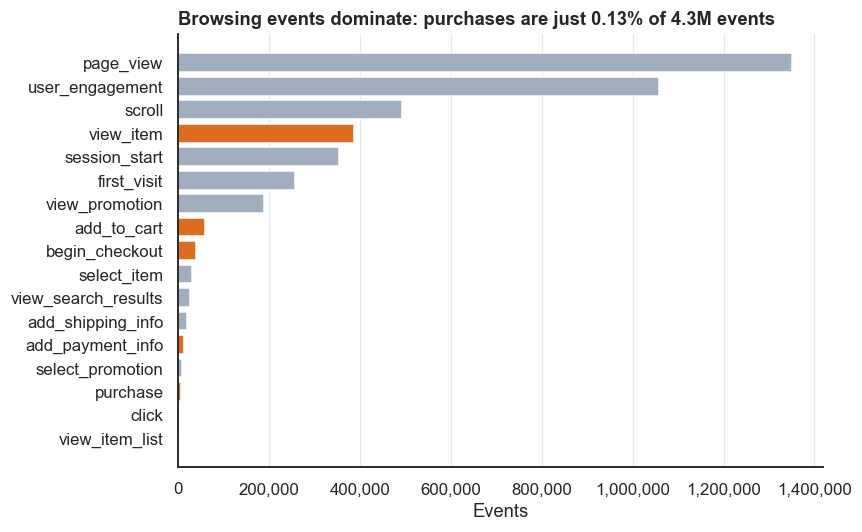

In [3]:
events = load("01_dq_events_by_name.csv")
fig, ax = plt.subplots(figsize=(8, 5))
colors = [ORANGE if e in {"view_item", "add_to_cart", "begin_checkout", "add_payment_info", "purchase"} else GREY for e in events.event_name]
ax.barh(events.event_name[::-1], events.events[::-1], color=colors[::-1])
thousands(ax)
light_grid(ax, "x")
ax.set_xlabel("Events")
ax.set_title("Browsing events dominate: purchases are just 0.13% of 4.3M events")
plt.tight_layout()
plt.show()

Page views, engagement and scroll events make up about two thirds of all traffic, while the funnel events (orange) are a small slice. Purchases are 5,692 raw events, which later shrinks after removing repeats and empty records.

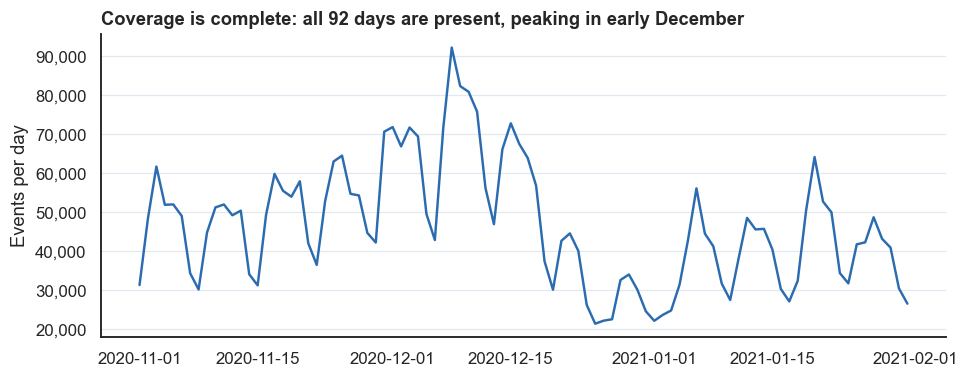

In [4]:
daily = load("01_dq_daily_events.csv")
daily["event_date"] = pd.to_datetime(daily["event_date"])
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(daily.event_date, daily.events, color=BLUE, lw=1.6)
thousands(ax, "y")
light_grid(ax, "y")
ax.set_ylabel("Events per day")
ax.set_title("Coverage is complete: all 92 days are present, peaking in early December")
plt.tight_layout()
plt.show()

There are no missing days. Traffic peaks in the first half of December and drops to its lowest points on 25 December and 1 January, so any holiday comparison has to be made against the early-November baseline and never year over year (there is no prior-year data).

## 3. Data quality

Google deliberately hides some values as `(data deleted)`, `<Other>` or nulls. They are reported here rather than silently dropped, and each analysis says how it handles them.

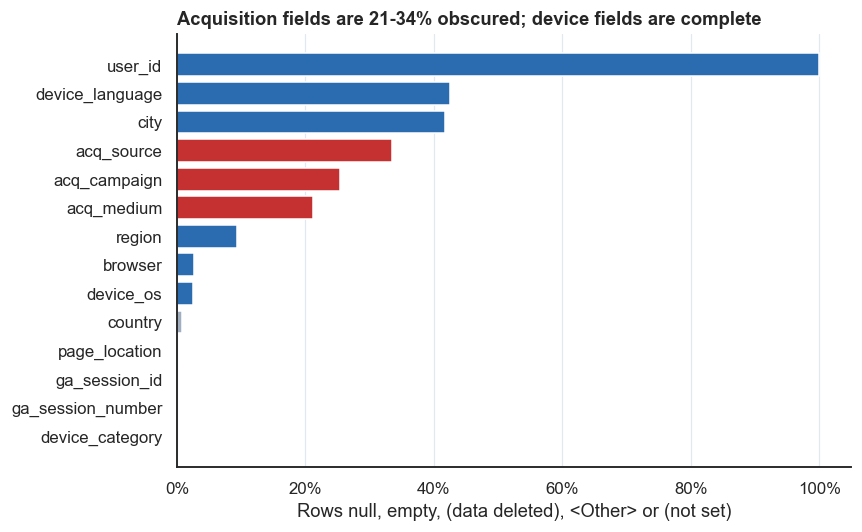

In [5]:
obs = load("01_dq_obscured_values.csv").sort_values("unusable_pct", ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
colors = [RED if c.startswith("acq_") else (GREY if p < 1 else BLUE) for c, p in zip(obs.column_name, obs.unusable_pct)]
ax.barh(obs.column_name, obs.unusable_pct, color=colors)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
light_grid(ax, "x")
ax.set_xlabel("Rows null, empty, (data deleted), <Other> or (not set)")
ax.set_title("Acquisition fields are 21-34% obscured; device fields are complete")
plt.tight_layout()
plt.show()

`user_id` is 100% null, so every user count uses `user_pseudo_id`. The acquisition fields (red) are the weak spot: 33.5% of events have an obscured source and 21.2% an obscured medium, so the channel analysis gets its own rows for obscured values. Country is only 0.75% `(not set)` but city is 41.8%, so city is not used. `device_category`, `ga_session_id` and `ga_session_number` are never missing, which makes the device and session logic reliable.

In [6]:
purchases = load("01_dq_purchases.csv").iloc[0]
sessions_checks = load("02_sessions_checks.csv").iloc[0]
clean = pd.DataFrame({
    "": ["Raw purchase events", "Clean orders"],
    "Count": [f"{purchases.purchase_events:,.0f}", f"{sessions_checks.orders:,.0f}"],
    "Revenue (USD)": [f"${purchases.total_revenue_usd:,.0f}", f"${sessions_checks.revenue_usd:,.0f}"],
})
clean

,,Count,Revenue (USD)
0,Raw purchase events,"5,692","$362,165"
1,Clean orders,"4,907","$339,457"


Raw purchase events overstate orders. Some transactions are logged more than once (326 transaction ids repeat, 335 extra events), and 883 purchase events have no usable transaction id, 450 of them with $0 revenue. An order is therefore one distinct real `transaction_id` (earliest event), plus id-less purchases that carry revenue. That gives **4,907 orders and $339,457**, about 6% less revenue than the raw events suggest.

In [7]:
start = load("01_dq_new_vs_returning_at_start.csv").iloc[0]
print(f"{start.returning_at_first_sight:,.0f} of {start.users:,.0f} users ({start.returning_at_first_sight_pct:.1f}%) already look 'returning' the first time they appear.")

9,006 of 270,154 users (3.3%) already look 'returning' the first time they appear.


Because the data starts on 1 Nov 2020, users who visited earlier look new. The session-number parameter fixes this: a user is **new** only if their lowest `ga_session_number` is 1 (261,148 users) and **returning** otherwise (9,006 users, 3.3%).

### Tracking gaps over time

A day-by-day check of each funnel event (done after the first analyses, when a surprising number appeared) shows that tracking was not steady across the 92 days. Three gaps matter, and each one is handled in the analysis it touches.

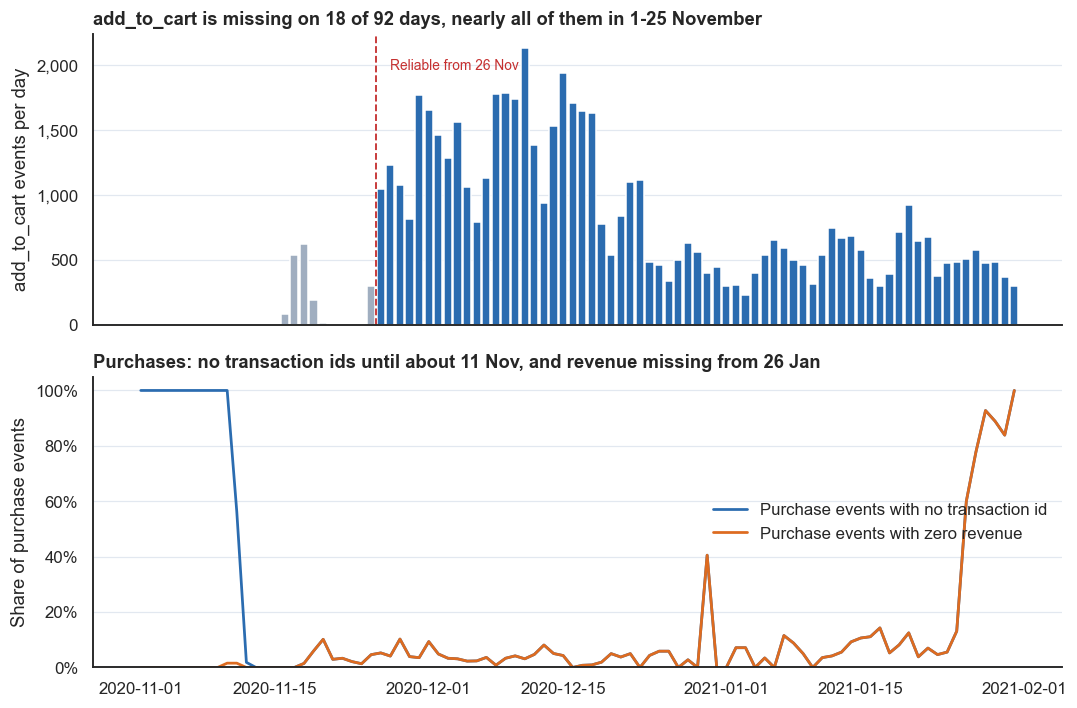

18 days have no add_to_cart events at all.
26-31 Jan: 232 of 282 purchase events have zero revenue (82%).


In [8]:
trk = load("01_dq_daily_tracking.csv")
trk["event_date"] = pd.to_datetime(trk.event_date)
CART_START = pd.Timestamp("2020-11-26")

fig, axes = plt.subplots(2, 1, figsize=(10, 6.6), sharex=True)
ax = axes[0]
ax.bar(trk.event_date, trk.add_to_cart_events, width=0.85, color=[GREY if d < CART_START else BLUE for d in trk.event_date])
ax.axvline(CART_START - pd.Timedelta(hours=12), color=RED, ls="--", lw=1.2)
ax.text(CART_START + pd.Timedelta(days=1), trk.add_to_cart_events.max() * 0.92, "Reliable from 26 Nov", color=RED, fontsize=9)
thousands(ax, "y")
light_grid(ax, "y")
ax.set_ylabel("add_to_cart events per day")
ax.set_title("add_to_cart is missing on 18 of 92 days, nearly all of them in 1-25 November")

ax = axes[1]
no_id = trk.purchase_events_without_id / trk.purchase_events * 100
zero_rev = trk.purchase_events_zero_revenue / trk.purchase_events * 100
ax.plot(trk.event_date, no_id, color=BLUE, lw=1.8, label="Purchase events with no transaction id")
ax.plot(trk.event_date, zero_rev, color=ORANGE, lw=1.8, label="Purchase events with zero revenue")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
light_grid(ax, "y")
ax.set_ylim(0, 105)
ax.legend(frameon=False, loc="center right")
ax.set_ylabel("Share of purchase events")
ax.set_title("Purchases: no transaction ids until about 11 Nov, and revenue missing from 26 Jan")
plt.tight_layout()
plt.show()

zero_days = int((trk.add_to_cart_events == 0).sum())
late = trk[trk.event_date >= "2021-01-26"]
print(f"{zero_days} days have no add_to_cart events at all.")
print(f"26-31 Jan: {int(late.purchase_events_zero_revenue.sum())} of {int(late.purchase_events.sum())} purchase events have zero revenue ({late.purchase_events_zero_revenue.sum() / late.purchase_events.sum() * 100:.0f}%).")

**1. Add to cart (1-25 November).** `add_to_cart` does not fire on most of the first 25 days (it appears briefly on 16-20 November and then reliably from 26 November), although every other funnel event is present daily. Counting the whole period would understate add-to-cart and make it look as if many users reach checkout "without" a cart. The **funnel, and every cart step in the channel and device comparisons, therefore uses only sessions from 26 November onward** (67 days, 75% of the sessions).

**2. Transaction ids (1-11 November).** About 460 purchase events in the first days carry revenue but no transaction id, so repeated events cannot be removed by id there. Among id-less purchases with revenue, 35 of 456 repeat inside the same session at the same revenue, close to the 7% repeat rate seen where ids exist. Across the whole project that is about 0.7% of orders and is left in; for the seasonality comparison it matters more, because all of it falls in the early-November baseline (about 5% of the baseline's 645 orders), so holiday uplifts are, if anything, understated.

**3. Revenue (26-31 January).** Purchase events keep firing at 30-70 a day, but 232 of the 282 events in the last six days have no revenue (all 19 on 31 January). Under the order rule they are not counted as orders, so orders and revenue for those days are undercounted by up to about 230 orders (4.7% of the total). **The seasonality analysis compares January on 1-25 January only**, and treats the last six days separately. Other analyses include those days, which lowers their totals slightly.

## 4. Funnel analysis

**Question:** which stage loses the largest share of potential customers?

The main funnel counts **users** and is **open**: a stage counts everyone who reached it, even if an earlier event was never recorded. A session-level version and a strict-sequence check are shown alongside. `add_shipping_info` is a diagnostic step, not one of the plan's seven stages.

**The funnel uses only users active from 26 November 2020 onward**, because `add_to_cart` events are missing for most of 1-25 November (see the tracking gaps above). The whole-period funnel is shown at the end for comparison, and it is visibly distorted.

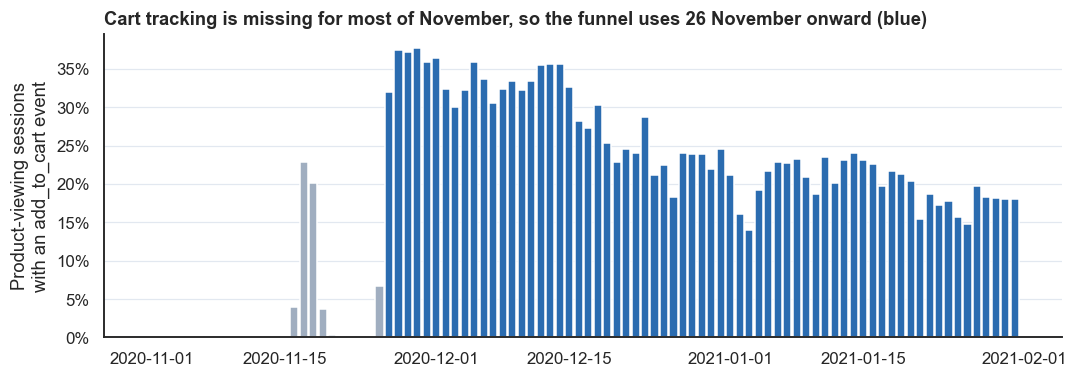

In [9]:
daily = load("04_cart_tracking_daily.csv")
daily["date"] = pd.to_datetime(daily["date"])
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.bar(daily.date, daily.cart_pct_of_product_view_sessions, width=0.85, color=[BLUE if w else GREY for w in daily.in_cart_window])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
light_grid(ax, "y")
ax.set_ylabel("Product-viewing sessions\nwith an add_to_cart event")
ax.set_title("Cart tracking is missing for most of November, so the funnel uses 26 November onward (blue)")
plt.tight_layout()
plt.show()

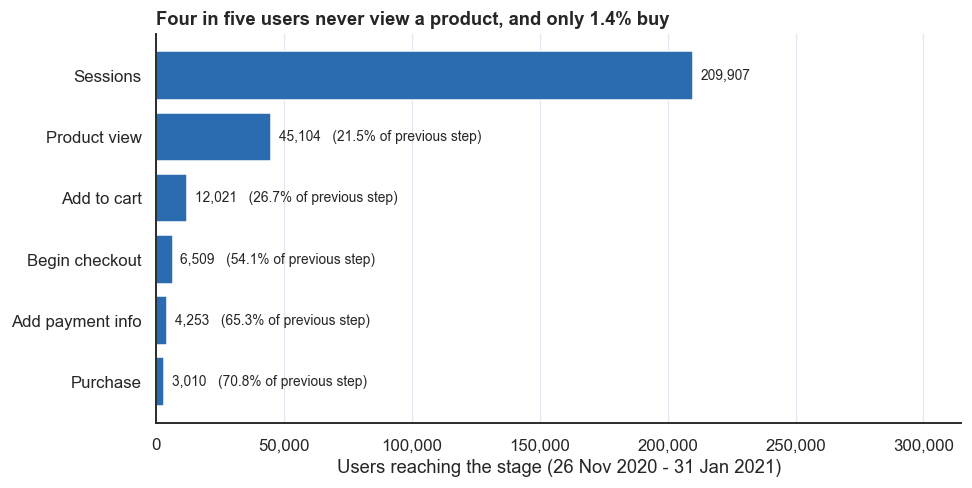

In [10]:
steps = load("04_funnel_steps.csv")
main = steps[~steps.is_diagnostic].reset_index(drop=True)
main["step_conv"] = main.users / main.users.shift(1) * 100  # from the counts, to avoid rounding twice

fig, ax = plt.subplots(figsize=(9, 4.6))
y = np.arange(len(main))[::-1]
ax.barh(y, main.users, color=BLUE)
for yi, row in zip(y, main.itertuples()):
    label = f"{row.users:,.0f}"
    if row.stage_order > 1:
        label += f"   ({row.step_conv:.1f}% of previous step)"
    ax.text(row.users + 3000, yi, label, va="center", fontsize=9)
ax.set_yticks(y)
ax.set_yticklabels(main.stage)
thousands(ax)
light_grid(ax, "x")
ax.set_xlim(0, main.users.max() * 1.5)
ax.set_xlabel("Users reaching the stage (26 Nov 2020 - 31 Jan 2021)")
ax.set_title("Four in five users never view a product, and only 1.4% buy")
plt.tight_layout()
plt.show()

Of 209,907 users in the window, 45,104 (21.5%) view a product, so **78.5% never do, the largest relative loss**. Among those who view a product, only 26.7% add to cart (a 73.4% loss, the second largest) and 54.1% of the users who add to cart go on to begin checkout (a 45.9% loss; 55.9% in a strict sequence, see below). Once checkout has begun, 34.7% never add payment details and 29.2% of those who do never complete the purchase. Overall, 3,010 users buy: **1.43% of all users and 6.7% of product viewers**.

In [11]:
show = steps[["stage", "users", "users_step_conversion_pct", "users_overall_conversion_pct", "users_drop_off", "users_drop_off_pct", "sessions", "sessions_step_conversion_pct"]].copy()
show.columns = ["Stage", "Users", "Step conv. %", "Overall conv. %", "Users lost", "Relative drop-off %", "Sessions", "Sessions step conv. %"]
show.style.format({"Users": "{:,.0f}", "Sessions": "{:,.0f}", "Users lost": "{:,.0f}"}, na_rep="").hide(axis="index")

Stage,Users,Step conv. %,Overall conv. %,Users lost,Relative drop-off %,Sessions,Sessions step conv. %
Sessions,"209,907",,100.000000,,,"271,105",
Product view,"45,104",21.490000,21.490000,"164,803",78.510000,"55,498",20.470000
Add to cart,"12,021",26.650000,5.730000,"33,083",73.350000,"14,576",26.260000
Begin checkout,"6,509",54.150000,3.100000,"5,512",45.850000,"7,432",50.990000
Add shipping info (diagnostic),"6,510",100.020000,3.100000,-1,-0.020000,"7,433",100.010000
Add payment info,"4,253",65.340000,2.030000,"2,256",34.660000,"4,951",66.620000
Purchase,"3,010",70.770000,1.430000,"1,243",29.230000,"3,244",65.520000


The session-level funnel gives the same ranking with slightly lower conversion (1.20% of sessions end in an order against 1.43% of users), because a user can browse in several sessions before buying. The diagnostic row shows that everyone who begins checkout also adds shipping info (the two events fire together), so the real loss inside checkout happens at the payment step.

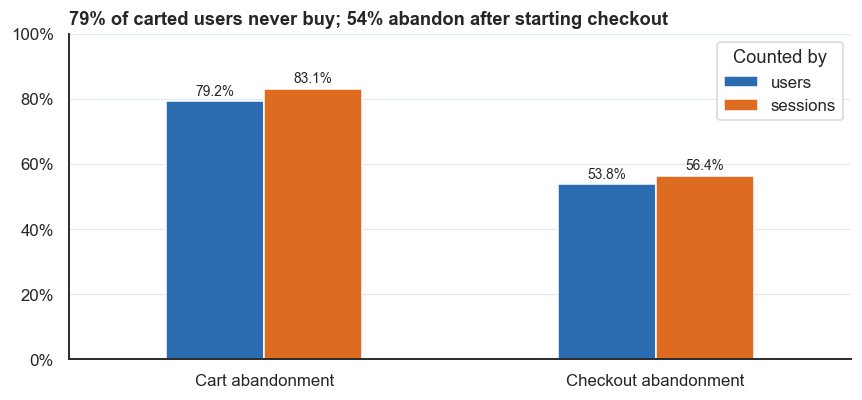

In [12]:
aband = load("04_funnel_abandonment.csv").set_index("level")
rates = pd.DataFrame({
    "Cart abandonment": aband.cart_abandonment_pct,
    "Checkout abandonment": aband.checkout_abandonment_pct,
}).loc[["users", "sessions"]]
ax = rates.T.plot.bar(figsize=(8, 3.8), color=[BLUE, ORANGE], rot=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
light_grid(ax, "y")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2, fontsize=9)
ax.set_ylim(0, 100)
ax.legend(title="Counted by")
ax.set_title("79% of carted users never buy; 54% abandon after starting checkout")
plt.tight_layout()
plt.show()

Cart abandonment is the share of users who added to cart and did not buy (79.2% of users, 83.1% of sessions). Checkout abandonment is the share of users who began checkout and did not buy (53.8% of users, 56.4% of sessions).

### Is the open funnel hiding something?

An open funnel counts a stage even when an earlier event is missing. Here some users reach checkout, and even purchase, without a recorded `add_to_cart` event, so the strict sequence below shows how much that matters.

In [13]:
open_checks = load("04_funnel_open_checks.csv").iloc[0]
strict = load("04_funnel_strict_check.csv").iloc[0]

compare = pd.DataFrame({
    "Stage": ["Product view", "Add to cart", "Begin checkout", "Add payment info", "Purchase"],
    "Open funnel (users)": main.users.iloc[1:].astype(int).to_list(),
    "Strict sequence (users)": [strict.product_view, strict.add_to_cart, strict.begin_checkout, strict.add_payment_info, strict.purchase],
}).astype({"Strict sequence (users)": int})
compare["Step conv. open %"] = (compare["Open funnel (users)"] / compare["Open funnel (users)"].shift(1) * 100).round(1)
compare["Step conv. strict %"] = (compare["Strict sequence (users)"] / compare["Strict sequence (users)"].shift(1) * 100).round(1)
compare.style.format({"Open funnel (users)": "{:,.0f}", "Strict sequence (users)": "{:,.0f}"}, na_rep="").hide(axis="index")

Stage,Open funnel (users),Strict sequence (users),Step conv. open %,Step conv. strict %
Product view,"45,104","45,104",,
Add to cart,"12,021","12,015",26.700000,26.600000
Begin checkout,"6,509","5,296",54.100000,44.100000
Add payment info,"4,253","3,453",65.300000,65.200000
Purchase,"3,010","2,499",70.800000,72.400000


**How much the cart step matters.** In the open funnel, 54.1% of users who add to cart begin checkout; in a strict sequence it is **44.1%**. The gap comes from users with no recorded `add_to_cart`: 1,212 of the 6,509 users who began checkout (18.6%) and 511 of the 3,010 purchasers (17.0%). That is far fewer than the whole-period numbers suggest (41.8% and 34.8%), which were inflated by the missing November events, but it is not zero: items added on an earlier visit before 26 November, a quick "buy now" path, or the event not firing could all explain it. The honest reading is that **the true cart-to-checkout loss lies between 46% and 56%**: only about half of the users who add to cart go on to start checkout.

In [14]:
whole = load("04_funnel_whole_period.csv")
w = whole[["stage", "users", "users_step_conversion_pct"]].copy()
reliable = main[["stage", "users_step_conversion_pct"]].copy()
cmp =w.merge(reliable, on="stage", how="left", suffixes=(" whole period", " from 26 Nov"))
cmp.columns = ["Stage", "Users (whole period)", "Step conv. % (whole period)", "Step conv. % (from 26 Nov)"]
cmp.style.format({"Users (whole period)": "{:,.0f}", "Step conv. % (whole period)": "{:.1f}", "Step conv. % (from 26 Nov)": "{:.1f}"}, na_rep="").hide(axis="index")

Stage,Users (whole period),Step conv. % (whole period),Step conv. % (from 26 Nov)
Sessions,"270,154",,
Product view,"61,252",22.7,21.5
Add to cart,"12,545",20.5,26.6
Begin checkout,"9,715",77.4,54.1
Add payment info,"5,751",59.2,65.3
Purchase,"4,055",70.5,70.8


**Why the whole-period funnel is not used.** Over all 92 days, add-to-cart looks worse (20.5% of viewers instead of 26.7%) and cart-to-checkout looks far better (77.4% instead of 54.1%), purely because add-to-cart was not being recorded for most of November. That version would have pointed the business at the wrong step.

**Summary.** Counting from 26 November, the biggest relative losses are (1) users who never view a product (78.5%), (2) viewers who never add to cart (73.4%), and (3) cart users who never start checkout (46% to 56%). Inside checkout, 34.7% never add payment details, and the last step loses 29.2%. Cart-to-checkout is a substantial loss, as the project plan suspected, and both the cart and payment steps are worth investigating.

## 5. Channel analysis

**Question:** which acquisition channels bring valuable customers, not just the most visitors?

This is **acquisition channel**: the earliest source and medium observed for each user that Google has not obscured. It is not the source of every visit, and about 10% of users show more than one real medium over the period. Values Google obscured get their own rows (`Other (obscured)` and `Data deleted`) instead of being dropped.

In [15]:
from scipy import stats


def wilson(successes, n, z=1.96):
    """95% Wilson score interval for a proportion."""
    p = successes / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return centre - half, centre + half


def two_prop_ztest(x1, n1, x2, n2):
    """Two-sided two-proportion z-test with a pooled standard error. Returns (diff, z, p)."""
    p1, p2 = x1 / n1, x2 / n2
    pooled = (x1 + x2) / (n1 + n2)
    se = np.sqrt(pooled * (1 - pooled) * (1 / n1 + 1 / n2))
    z = (p1 - p2) / se
    return p1 - p2, z, 2 * stats.norm.sf(abs(z))


perf = load("05_channel_performance.csv")
channels = perf[perf.acq_channel != "All users"].copy()
overall = perf[perf.acq_channel == "All users"].iloc[0]

table = channels[["acq_channel", "users", "pct_of_users", "purchasers", "conversion_rate_pct", "revenue_usd", "pct_of_revenue", "revenue_per_user", "aov"]].copy()
table.columns = ["Channel", "Users", "% of users", "Buyers", "Conversion %", "Revenue (USD)", "% of revenue", "Revenue / user", "AOV"]
table.style.format({"Users": "{:,.0f}", "Buyers": "{:,.0f}", "Revenue (USD)": "${:,.0f}", "Revenue / user": "${:.2f}", "AOV": "${:.2f}"}).hide(axis="index")

Channel,Users,% of users,Buyers,Conversion %,Revenue (USD),% of revenue,Revenue / user,AOV
Organic,"104,122",38.540000,"1,610",1.550000,"$131,260",38.670000,$1.26,$67.38
Direct,"66,233",24.520000,"1,068",1.610000,"$95,518",28.140000,$1.44,$72.25
Referral,"42,669",15.790000,889,2.080000,"$77,425",22.810000,$1.81,$71.29
Paid (cpc),"14,441",5.350000,209,1.450000,"$17,997",5.300000,$1.25,$74.68
Other (obscured),"40,863",15.130000,240,0.590000,"$15,058",4.440000,$0.37,$56.40
Data deleted,"1,826",0.680000,39,2.140000,"$2,199",0.650000,$1.20,$51.14


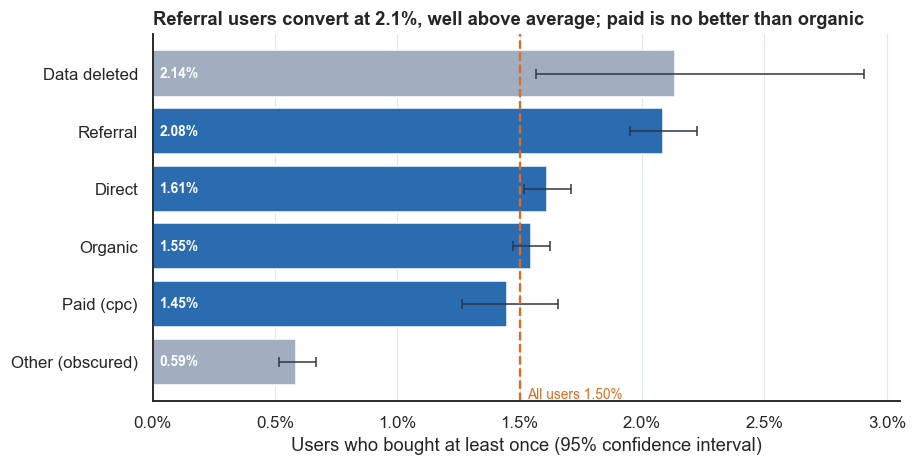

In [16]:
channels["lo"], channels["hi"] = zip(*[wilson(b, n) for b, n in zip(channels.purchasers, channels.users)])
plot = channels.copy()
plot["conv"] = plot.purchasers / plot.users * 100
plot["err_lo"] = plot.conv - plot.lo * 100
plot["err_hi"] = plot.hi * 100 - plot.conv
plot = plot.sort_values("conv")

fig, ax = plt.subplots(figsize=(8.5, 4.4))
colors = [GREY if o else BLUE for o in plot.is_obscured]
ax.barh(plot.acq_channel, plot.conv, xerr=[plot.err_lo, plot.err_hi], color=colors, error_kw={"ecolor": "#2d3748", "capsize": 3, "lw": 1})
ax.axvline(overall.conversion_rate_pct, color=ORANGE, ls="--", lw=1.5)
ax.text(overall.conversion_rate_pct + 0.03, -0.45, f"All users {overall.conversion_rate_pct:.2f}%", color=ORANGE, fontsize=9, va="top")
for yi, c in enumerate(plot.conv):
    ax.text(0.03, yi, f"{c:.2f}%", va="center", color="white", fontsize=9, fontweight="bold")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
light_grid(ax, "x")
ax.set_xlabel("Users who bought at least once (95% confidence interval)")
ax.set_title("Referral users convert at 2.1%, well above average; paid is no better than organic")
plt.tight_layout()
plt.show()

In [17]:
organic = channels[channels.acq_channel == "Organic"].iloc[0]
referral = channels[channels.acq_channel == "Referral"].iloc[0]
paid = channels[channels.acq_channel == "Paid (cpc)"].iloc[0]
direct = channels[channels.acq_channel == "Direct"].iloc[0]

tests = []
for name, other in [("Referral vs Organic", referral), ("Paid (cpc) vs Organic", paid), ("Direct vs Organic", direct)]:
    diff, z, p = two_prop_ztest(other.purchasers, other.users, organic.purchasers, organic.users)
    tests.append({"Comparison": name, "Difference (pp)": diff * 100, "z": z, "p-value": p, "Significant (p < 0.05)": "yes" if p < 0.05 else "no"})
pd.DataFrame(tests).style.format({"Difference (pp)": "{:+.2f}", "z": "{:.2f}", "p-value": "{:.2g}"}).hide(axis="index")

Comparison,Difference (pp),z,p-value,Significant (p < 0.05)
Referral vs Organic,+0.54,7.22,5e-13,yes
Paid (cpc) vs Organic,-0.10,-0.91,0.36,no
Direct vs Organic,+0.07,1.07,0.28,no


**Referral is the standout.** Referral users are 15.8% of the audience but buy at **2.08% against 1.55% for organic** (a gap of 0.54 percentage points, z = 7.2, p < 0.001), and each referral user is worth $1.82 in revenue against a $1.26 average. **Paid (cpc) gives no premium**: 1.45% against 1.55% for organic is not a significant difference (p = 0.36), and revenue per user ($1.25) matches organic ($1.26). Paid does have the highest average order value ($74.68), but the sample has no ad-spend data, so this says nothing about return on spend. Direct (1.61%) is also above organic, but that gap is not statistically significant. The grey `Data deleted` bar (2.14%) is the highest on the chart, but it covers only 1,826 users, so its interval is very wide and it is not evidence of a strong channel.

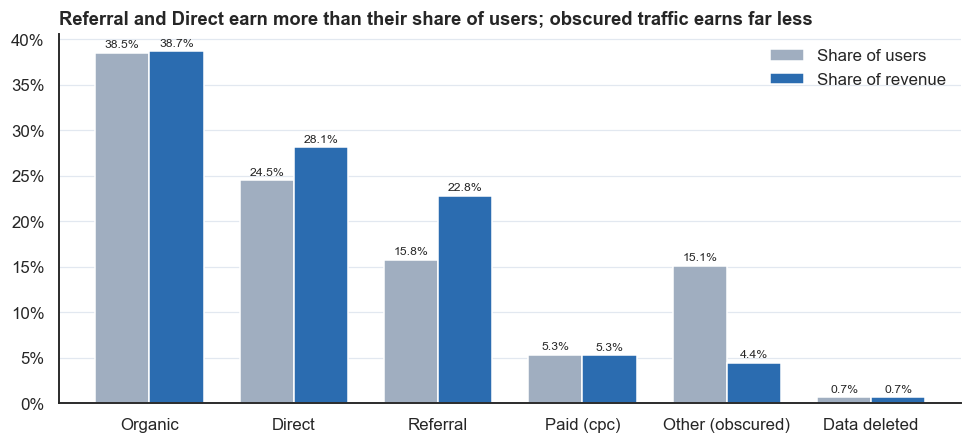

In [18]:
share = channels.set_index("acq_channel")[["pct_of_users", "pct_of_revenue"]].loc[["Organic", "Direct", "Referral", "Paid (cpc)", "Other (obscured)", "Data deleted"]]
ax = share.plot.bar(figsize=(9, 4.2), color=[GREY, BLUE], rot=0, width=0.75)
light_grid(ax, "y")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)
ax.legend(["Share of users", "Share of revenue"], frameon=False)
ax.set_xlabel("")
ax.set_title("Referral and Direct earn more than their share of users; obscured traffic earns far less")
plt.tight_layout()
plt.show()

Organic earns almost exactly its share (38.5% of users, 38.7% of revenue). Referral punches above its weight (15.8% of users, 22.8% of revenue) and so does Direct (24.5% and 28.1%). The `Other (obscured)` group is the opposite: **15.1% of users but only 4.4% of revenue** ($0.37 per user, 0.59% conversion). Those users also rarely come back (1.04 sessions per user against 1.33 overall) and stall in checkout, as the next chart shows.

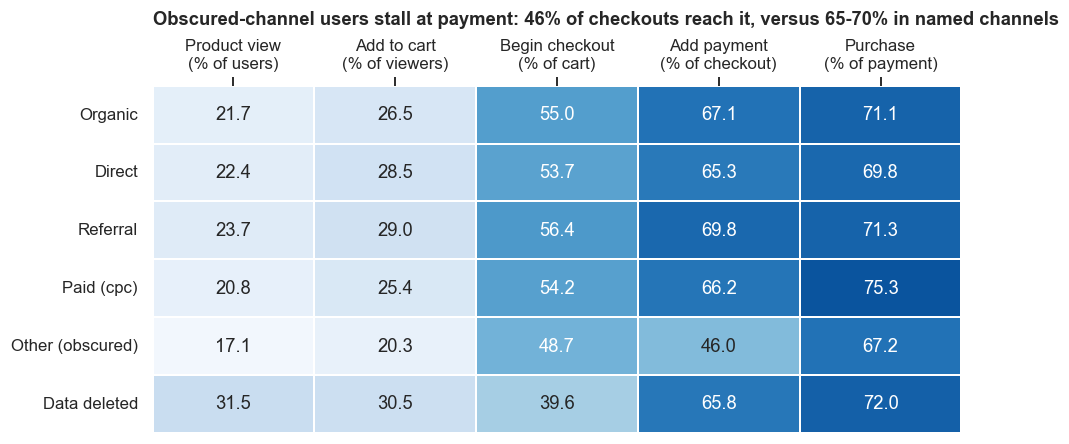

In [19]:
funnel = load("05_channel_funnel.csv").set_index("acq_channel").loc[["Organic", "Direct", "Referral", "Paid (cpc)", "Other (obscured)", "Data deleted"]]
heat = funnel[["view_pct_of_users", "cart_pct_of_view", "checkout_pct_of_cart", "payment_pct_of_checkout", "purchase_pct_of_payment"]]
heat.columns = ["Product view\n(% of users)", "Add to cart\n(% of viewers)", "Begin checkout\n(% of cart)", "Add payment\n(% of checkout)", "Purchase\n(% of payment)"]
fig, ax = plt.subplots(figsize=(9, 4.2))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="Blues", cbar=False, linewidths=1, linecolor="white", ax=ax, vmin=15, vmax=85)
ax.set_ylabel("")
ax.xaxis.tick_top()
ax.set_title("Obscured-channel users stall at payment: 46% of checkouts reach it, versus 65-70% in named channels", pad=40)
plt.tight_layout()
plt.show()

The funnel steps use users active from 26 November onward, because `add_to_cart` is missing for most of 1-25 November (see the tracking gaps in the data quality section). Across the four named channels the funnel looks alike: about 25% to 29% of product viewers add to cart, 54% to 56% of cart users begin checkout, and 70% to 75% of payments complete. The main differences are that referral users are more likely to view a product (23.7% against 21.7% for organic), to add to cart (29.0% against 26.5%) and to continue through checkout (69.8% reach payment against 67.1%). The obscured group loses people at every step: 17.1% view a product, 20.3% of those add to cart, and only 46.0% of checkout starters add payment details. Because Google hides what these users actually are, this could be low-quality traffic, bots, or a tracking artefact; the sample cannot say which.

In [20]:
sources = load("05_channel_sources.csv")
src = sources[["acq_channel", "acq_medium", "acq_source", "users", "conversion_rate_pct", "revenue_usd", "revenue_per_user"]].copy()
src.columns = ["Channel", "Medium", "Source", "Users", "Conversion %", "Revenue (USD)", "Revenue / user"]
src.style.format({"Users": "{:,.0f}", "Revenue (USD)": "${:,.0f}", "Revenue / user": "${:.2f}"}).hide(axis="index")

Channel,Medium,Source,Users,Conversion %,Revenue (USD),Revenue / user
Organic,organic,google,"95,255",1.550000,"$120,324",$1.26
Direct,(none),(direct),"66,233",1.610000,"$95,518",$1.44
Other (obscured),,,"40,862",0.590000,"$15,058",$0.37
Referral,referral,,"26,306",1.780000,"$39,363",$1.50
Referral,referral,shop.googlemerchandisestore.com,"16,362",2.580000,"$38,062",$2.33
Paid (cpc),cpc,google,"14,441",1.450000,"$17,997",$1.25
Organic,organic,,"8,867",1.470000,"$10,936",$1.23
Data deleted,(data deleted),(data deleted),"1,785",2.130000,"$2,167",$1.21


**Caveats for the channel analysis.** The best-performing referral source is `shop.googlemerchandisestore.com` (2.58% conversion, $2.33 per user, 16,362 users), which looks like the store's own domain rather than an outside partner; if so, it is a cross-domain or self-referral effect and should not be read as a marketing channel. The other referral users, whose source Google obscured, still convert at 1.78%, above organic. Everything here is observational: the channels differ in audience as well as in quality, so these results show where value comes from, not what would happen if spend moved.

## 6. Device and country analysis

**Question:** where does the funnel diverge by device, and which markets deserve focus?

A device belongs to a *session* (one person can use a phone and a laptop), so the device comparison counts **sessions**. A user-level version, using each user's first device, is used as a robustness check. Funnel stages are open, as before.

Overall performance (orders, revenue, conversion) uses the whole period. The step-by-step funnel uses sessions from 26 November onward, because `add_to_cart` is missing for most of 1-25 November (see the tracking gaps in the data quality section).

In [21]:
perf = load("06_device_performance.csv").set_index("device_category").loc[["desktop", "mobile", "tablet"]]
dev = load("06_device_funnel_sessions.csv").set_index("device_category").loc[["desktop", "mobile", "tablet"]]

summary = perf[["sessions", "pct_of_sessions", "orders", "revenue_usd", "pct_of_revenue", "conversion_rate_pct", "revenue_per_session", "aov"]].reset_index()
summary.columns = ["Device", "Sessions", "% of sessions", "Orders", "Revenue (USD)", "% of revenue", "Conversion % (sessions)", "Revenue / session", "AOV"]
summary.style.format({"Sessions": "{:,.0f}", "Orders": "{:,.0f}", "Revenue (USD)": "${:,.0f}", "Revenue / session": "${:.2f}", "AOV": "${:.2f}"}).hide(axis="index")

Device,Sessions,% of sessions,Orders,Revenue (USD),% of revenue,Conversion % (sessions),Revenue / session,AOV
desktop,"208,942",58.020000,"2,818","$196,583",57.910000,1.210000,$0.94,$69.76
mobile,"143,185",39.760000,"1,997","$136,921",40.340000,1.270000,$0.96,$68.56
tablet,"8,002",2.220000,92,"$5,953",1.750000,1.140000,$0.74,$64.71


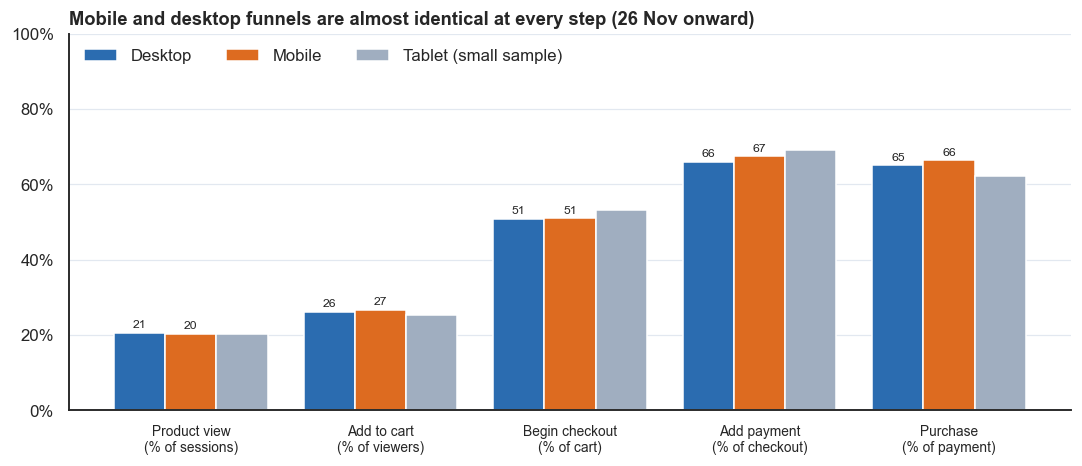

In [22]:
steps = [
    ("Product view\n(% of sessions)", "view_pct_of_sessions"),
    ("Add to cart\n(% of viewers)", "cart_pct_of_view"),
    ("Begin checkout\n(% of cart)", "checkout_pct_of_cart"),
    ("Add payment\n(% of checkout)", "payment_pct_of_checkout"),
    ("Purchase\n(% of payment)", "purchase_pct_of_payment"),
]
x = np.arange(len(steps))
width = 0.27
fig, ax = plt.subplots(figsize=(10, 4.4))
palette = {"desktop": BLUE, "mobile": ORANGE, "tablet": GREY}
for i, device in enumerate(["desktop", "mobile", "tablet"]):
    vals = [dev.loc[device, col] for _, col in steps]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=device.capitalize() + (" (small sample)" if device == "tablet" else ""), color=palette[device])
    if device != "tablet":
        ax.bar_label(bars, fmt="%.0f", padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([s for s, _ in steps], fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
light_grid(ax, "y")
ax.set_ylim(0, 100)
ax.legend(frameon=False, ncol=3, loc="upper left")
ax.set_title("Mobile and desktop funnels are almost identical at every step (26 Nov onward)")
plt.tight_layout()
plt.show()

In [23]:
stages = [
    ("Product view (of sessions)", "product_view", "sessions"),
    ("Add to cart (of viewers)", "add_to_cart", "product_view"),
    ("Begin checkout (of cart)", "begin_checkout", "add_to_cart"),
    ("Add payment (of checkout)", "add_payment_info", "begin_checkout"),
    ("Purchase (of payment)", "purchase", "add_payment_info"),
]
rows = []
for label, num, den in stages:
    diff, z, p = two_prop_ztest(dev.loc["mobile", num], dev.loc["mobile", den], dev.loc["desktop", num], dev.loc["desktop", den])
    rows.append({
        "Step": label,
        "Mobile %": dev.loc["mobile", num] / dev.loc["mobile", den] * 100,
        "Desktop %": dev.loc["desktop", num] / dev.loc["desktop", den] * 100,
        "Gap (pp)": diff * 100,
        "z": z,
        "p-value": p,
        "Significant (p < 0.05)": "yes" if p < 0.05 else "no",
    })
# overall conversion uses the whole period, which does not depend on the cart events
diff, z, p = two_prop_ztest(perf.loc["mobile", "purchase"], perf.loc["mobile", "sessions"], perf.loc["desktop", "purchase"], perf.loc["desktop", "sessions"])
rows.append({
    "Step": "Overall conversion (of sessions, whole period)",
    "Mobile %": perf.loc["mobile", "purchase"] / perf.loc["mobile", "sessions"] * 100,
    "Desktop %": perf.loc["desktop", "purchase"] / perf.loc["desktop", "sessions"] * 100,
    "Gap (pp)": diff * 100,
    "z": z,
    "p-value": p,
    "Significant (p < 0.05)": "yes" if p < 0.05 else "no",
})
device_tests = pd.DataFrame(rows)
biggest = device_tests.loc[device_tests["Gap (pp)"].abs().idxmax(), "Step"]
print(f"Biggest mobile-vs-desktop gap by size: {biggest}")
device_tests.style.format({"Mobile %": "{:.2f}", "Desktop %": "{:.2f}", "Gap (pp)": "{:+.2f}", "z": "{:+.2f}", "p-value": "{:.3f}"}).hide(axis="index")

Biggest mobile-vs-desktop gap by size: Add payment (of checkout)


Step,Mobile %,Desktop %,Gap (pp),z,p-value,Significant (p < 0.05)
Product view (of sessions),20.31,20.59,-0.28,-1.77,0.077,no
Add to cart (of viewers),26.60,26.08,+0.52,+1.36,0.175,no
Begin checkout (of cart),51.00,50.90,+0.10,+0.11,0.910,no
Add payment (of checkout),67.42,65.97,+1.45,+1.29,0.198,no
Purchase (of payment),66.42,65.02,+1.40,+1.01,0.314,no
"Overall conversion (of sessions, whole period)",1.27,1.21,+0.06,+1.60,0.109,no


In [24]:
tablet_diff, tablet_z, tablet_p = two_prop_ztest(dev.loc["tablet", "purchase"], dev.loc["tablet", "add_payment_info"], dev.loc["desktop", "purchase"], dev.loc["desktop", "add_payment_info"])
users_dev = load("06_device_funnel_users.csv").set_index("device_category")
u_diff, u_z, u_p = two_prop_ztest(users_dev.loc["mobile", "purchase"], users_dev.loc["mobile", "users"], users_dev.loc["desktop", "purchase"], users_dev.loc["desktop", "users"])
print(f"Tablet vs desktop, purchase step ({int(dev.loc['tablet', 'add_payment_info'])} tablet payment sessions): gap {tablet_diff * 100:+.2f} pp, p = {tablet_p:.3f}")
print(f"Robustness, user level (first device): mobile {users_dev.loc['mobile', 'conversion_rate_pct']:.2f}% vs desktop {users_dev.loc['desktop', 'conversion_rate_pct']:.2f}%, gap {u_diff * 100:+.2f} pp, p = {u_p:.3f}")

Tablet vs desktop, purchase step (114 tablet payment sessions): gap -2.74 pp, p = 0.548
Robustness, user level (first device): mobile 1.54% vs desktop 1.48%, gap +0.06 pp, p = 0.204


**The device is not where the funnel breaks.** Desktop and mobile follow the same path: about 20% of sessions view a product, 26% of viewers add to cart, 51% of those continue to checkout, 66-67% add payment and 65-66% complete. No step differs significantly (every p-value is above 0.07). The largest gap in size is at the payment step, and it favours mobile (67.4% against 66.0%, p = 0.20). Over the whole period, mobile sessions convert at 1.27% against 1.21% on desktop (p = 0.11, not significant). The user-level check agrees (1.54% against 1.48%, p = 0.20). Mobile is 40% of sessions and 40% of revenue, in line with its traffic.

**Tablet** is only 2.2% of sessions and its biggest gap (2.7 points lower at the purchase step) rests on 114 payment sessions, so it is too small to be a finding (p = 0.55). Average order value is similar across devices ($64.71 to $69.76).

So this analysis does **not** support the idea that mobile checkout is the problem. A mobile checkout redesign would not be justified by this data; the loss points identified in the funnel affect all devices alike.

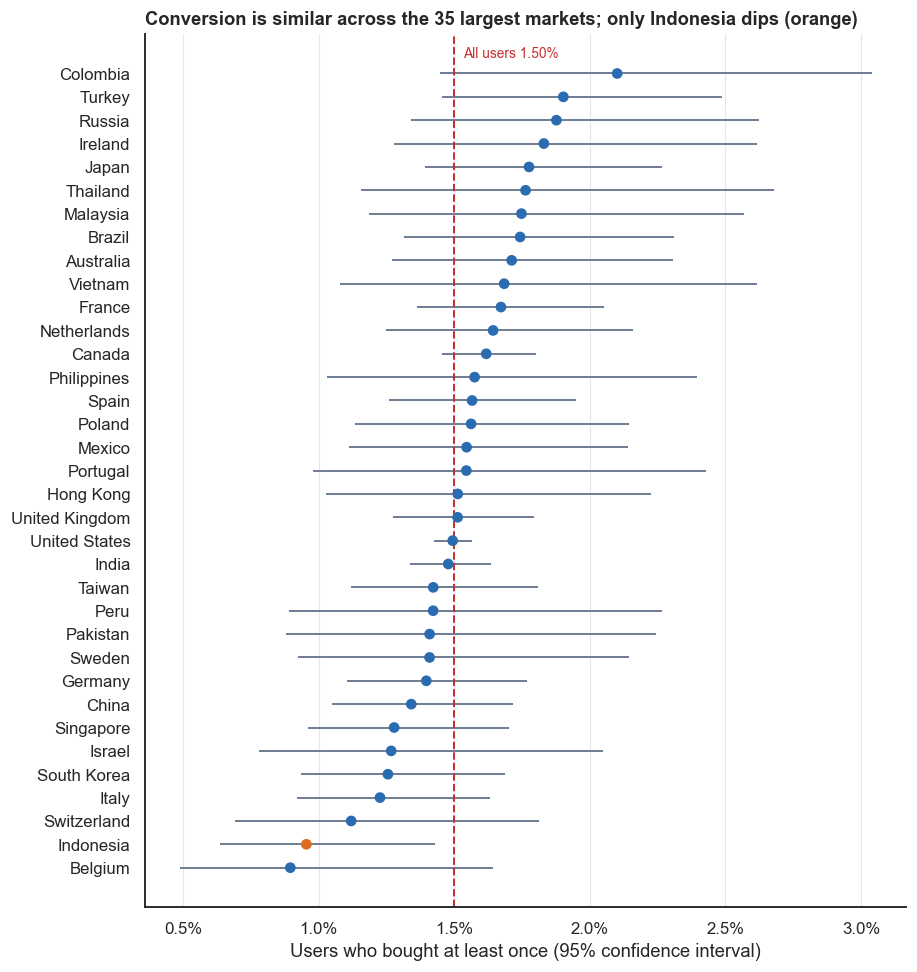

35 countries have at least 1,000 users and hold 92.4% of all users.
Nominally significant vs the rest (p < 0.05, uncorrected): 1. After Bonferroni correction (p < 0.0014): 0.


In [25]:
c = load("06_country_performance.csv")
total_users, total_buyers = c.users.sum(), c.purchasers.sum()
MIN_USERS = 1000
big = c[(c.users >= MIN_USERS) & (c.country != "(not set)")].copy()

res = []
for r in big.itertuples():
    diff, z, p = two_prop_ztest(r.purchasers, r.users, total_buyers - r.purchasers, total_users - r.users)
    lo, hi = wilson(r.purchasers, r.users)
    res.append({"country": r.country, "users": r.users, "buyers": r.purchasers, "conv": r.purchasers / r.users * 100, "lo": lo * 100, "hi": hi * 100,
                "diff_vs_rest": diff * 100, "p": p, "revenue": r.revenue_usd, "pct_users": r.pct_of_users, "pct_revenue": r.pct_of_revenue})
res = pd.DataFrame(res).sort_values("conv")
overall_conv = total_buyers / total_users * 100

fig, ax = plt.subplots(figsize=(8.5, 9))
colors = [ORANGE if p < 0.05 else BLUE for p in res.p]
ax.hlines(res.country, res.lo, res.hi, color="#718096", lw=1.3)
ax.scatter(res.conv, res.country, color=colors, zorder=3, s=36)
ax.axvline(overall_conv, color=RED, ls="--", lw=1.3)
ax.text(overall_conv + 0.03, len(res) - 0.3, f"All users {overall_conv:.2f}%", color=RED, fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
light_grid(ax, "x")
ax.set_xlabel("Users who bought at least once (95% confidence interval)")
ax.set_title("Conversion is similar across the 35 largest markets; only Indonesia dips (orange)")
plt.tight_layout()
plt.show()
print(f"{len(res)} countries have at least {MIN_USERS:,} users and hold {res.users.sum() / total_users * 100:.1f}% of all users.")
print(f"Nominally significant vs the rest (p < 0.05, uncorrected): {(res.p < 0.05).sum()}. After Bonferroni correction (p < {0.05 / len(res):.4f}): {(res.p < 0.05 / len(res)).sum()}.")

In [26]:
watch = res.sort_values("conv").head(5)[["country", "users", "buyers", "conv", "diff_vs_rest", "p"]].copy()
watch.columns = ["Country", "Users", "Buyers", "Conversion %", "Gap vs rest (pp)", "p-value"]
print("Lowest conversion among markets with 1,000+ users:")
display(watch.style.format({"Users": "{:,.0f}", "Conversion %": "{:.2f}", "Gap vs rest (pp)": "{:+.2f}", "p-value": "{:.3f}"}).hide(axis="index"))

small = c[c.users < MIN_USERS].sort_values("conversion_rate_pct", ascending=False).head(5)[["country", "users", "purchasers", "conversion_rate_pct"]].copy()
small.columns = ["Country", "Users", "Buyers", "Conversion %"]
print("Why a minimum user count matters: the top 'conversion' scores among tiny markets")
display(small.style.format({"Users": "{:,.0f}", "Conversion %": "{:.2f}"}).hide(axis="index"))

Lowest conversion among markets with 1,000+ users:


Country,Users,Buyers,Conversion %,Gap vs rest (pp),p-value
Belgium,"1,116",10,0.90,-0.61,0.096
Indonesia,"2,408",23,0.96,-0.55,0.027
Switzerland,"1,428",16,1.12,-0.38,0.236
Italy,"3,750",46,1.23,-0.28,0.164
South Korea,"3,424",43,1.26,-0.25,0.235


Why a minimum user count matters: the top 'conversion' scores among tiny markets


Country,Users,Buyers,Conversion %
Uruguay,104,6,5.77
Macao,55,2,3.64
Malta,57,2,3.51
Dominican Republic,154,5,3.25
Guatemala,93,3,3.23


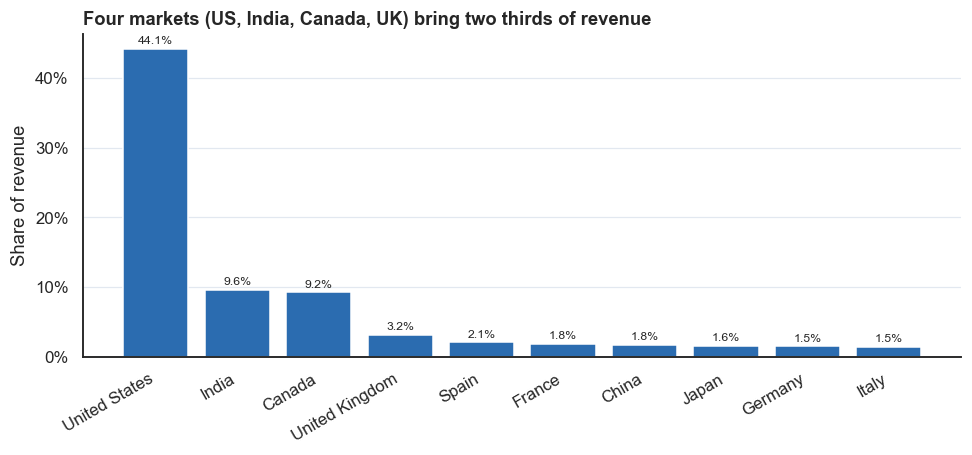

In [27]:
top = c.sort_values("revenue_usd", ascending=False).head(10).copy()
top["cum_pct"] = top.pct_of_revenue.cumsum()
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(top.country, top.pct_of_revenue, color=BLUE)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=2, fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
light_grid(ax, "y")
ax.set_ylabel("Share of revenue")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_title("Four markets (US, India, Canada, UK) bring two thirds of revenue")
plt.tight_layout()
plt.show()

**Country conversion does not separate the markets.** Of 109 countries, 35 have at least 1,000 users and together hold 92.4% of all users. Their conversion rates range from about 1% to 2.1% around the 1.50% average, but with this few buyers per country almost none of that is distinguishable from chance. Only Indonesia stands out (0.96% on 2,408 users, 23 buyers, p = 0.027), and that does not survive a correction for running 35 comparisons. Among markets with 3,000 or more users, Italy (1.23%), South Korea (1.26%) and Singapore (1.28%) have the lowest rates, and they are a watch list rather than a conclusion. Without a minimum user count the ranking would be dominated by tiny markets such as Uruguay (5.8% from 6 buyers).

**Revenue is concentrated, so focus follows size.** The United States (44.1% of revenue), India (9.6%), Canada (9.2%) and the United Kingdom (3.2%) bring 66% of revenue. Canada earns more than its 7.5% share of users (9.2% of revenue, $1.55 per user against $1.26 overall), mostly through a higher average order value ($76.88 against $69.18) and slightly higher conversion (1.62%, a gap that is not statistically significant). Country is a useful way to size the opportunity, but this sample does not show a market with a clearly broken funnel.

## 7. Product analysis

**Question:** which products attract attention but fail to sell, and which sell well without being noticed?

**How to read the product data.** The product item data in this GA4 sample has quirks that shape the definitions:

- **Views are impressions.** `view_item` events mostly fire on list pages and carry about 12 products each, and about 37% carry no items at all. A "view" here means the product was shown in a `view_item` event (counted once per event), not that someone opened its page.
- **Cart adds are partial.** Only 64% of `add_to_cart` events identify the product added, and the event is missing for most of 1-25 November (see the tracking gaps in the data quality section). The cart rates in the product table therefore use data from 26 November onward and are indicative only. The quadrants use view-to-purchase, which does not depend on cart events.
- **Purchases are solid.** They use the same cleaned orders as the rest of the project, and item revenue reconciles to order revenue within $45.
- **Names, not ids.** `item_id` is not a usable key (two id schemes exist), so products are keyed by name, with nine hand-matched spelling variants merged. The `item_category` field is a site-navigation section rather than a product category, so products are grouped by keywords in their name, which is approximate.

The classification uses the median impressions and median view-to-purchase rate of products with at least 1,000 impressions (the plan's "about 100 views" assumed detail-page views; impressions are far more numerous).

In [28]:
products = load("07_products.csv")
quadrants = load("07_product_quadrants.csv")
groups = load("07_product_groups.csv")
checks = load("07_product_checks.csv").iloc[0]
floor = products[products.meets_view_floor].copy()

print(f"{int(checks.products)} products in total; {int(checks.products_meeting_view_floor)} have at least 1,000 impressions and get a quadrant; {int(checks.products_sold)} sold at least once.")
print(f"Medians used: {floor.median_impressions.iloc[0]:,.0f} impressions and {floor.median_view_to_purchase_pct.iloc[0]:.3f}% view-to-purchase.")
print(f"Item revenue ${checks.item_revenue_usd:,.0f}, within ${abs(checks.item_minus_order_revenue_usd):.0f} of the order revenue.")

q = quadrants.copy()
q["revenue_per_1k_impressions"] = q.revenue_usd / q.impressions * 1000
q = q.set_index("quadrant").loc[["Strong products", "High traffic, low conversion", "Hidden winners", "Weak products"]].reset_index()
view = q[["quadrant", "products", "pct_of_impressions", "pct_of_revenue", "revenue_usd", "revenue_per_1k_impressions", "avg_unit_price"]].copy()
view.columns = ["Quadrant", "Products", "% of impressions", "% of revenue", "Revenue (USD)", "Revenue per 1,000 impressions", "Avg unit price"]
view.style.format({"% of impressions": "{:.1f}", "% of revenue": "{:.1f}", "Revenue (USD)": "${:,.0f}", "Revenue per 1,000 impressions": "${:.0f}", "Avg unit price": "${:.2f}"}).hide(axis="index")

419 products in total; 285 have at least 1,000 impressions and get a quadrant; 394 sold at least once.
Medians used: 5,493 impressions and 0.525% view-to-purchase.
Item revenue $339,412, within $45 of the order revenue.


Quadrant,Products,% of impressions,% of revenue,Revenue (USD),"Revenue per 1,000 impressions",Avg unit price
Strong products,45,21.6,42.2,"$128,963",$230,$22.05
"High traffic, low conversion",98,63.0,31.9,"$97,363",$59,$18.38
Hidden winners,98,10.2,24.1,"$73,621",$278,$18.55
Weak products,44,5.3,1.7,"$5,313",$38,$16.96


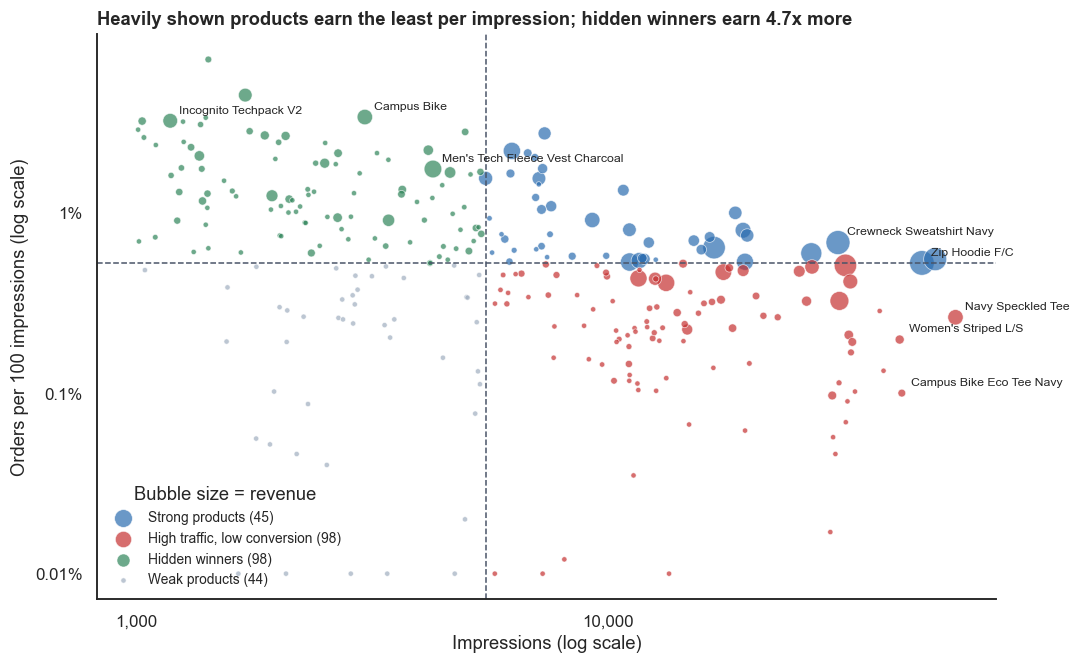

In [29]:
palette = {"Strong products": BLUE, "High traffic, low conversion": RED, "Hidden winners": "#2f855a", "Weak products": GREY}
fig, ax = plt.subplots(figsize=(10, 6.2))
for name, color in palette.items():
    d = floor[floor.quadrant == name]
    ax.scatter(d.impressions, d.view_to_purchase_pct.clip(lower=0.01), s=np.clip(d.revenue_usd / 40, 12, 260), color=color, alpha=0.7, label=f"{name} ({len(d)})", edgecolor="white", linewidth=0.5)
ax.axvline(floor.median_impressions.iloc[0], color="#4a5568", ls="--", lw=1)
ax.axhline(floor.median_view_to_purchase_pct.iloc[0], color="#4a5568", ls="--", lw=1)
ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:g}%"))
ax.set_xlabel("Impressions (log scale)")
ax.set_ylabel("Orders per 100 impressions (log scale)")
labels = pd.concat([
    floor[floor.quadrant == "Hidden winners"].nlargest(3, "revenue_usd"),
    floor[floor.quadrant == "High traffic, low conversion"].nlargest(3, "impressions"),
    floor[floor.quadrant == "Strong products"].nlargest(2, "revenue_usd"),
])
for r in labels.itertuples():
    ax.annotate(r.item_name.replace("Google ", ""), (r.impressions, max(r.view_to_purchase_pct, 0.01)), xytext=(6, 5), textcoords="offset points", fontsize=8)
ax.legend(frameon=False, loc="lower left", fontsize=9, title="Bubble size = revenue")
ax.set_title("Heavily shown products earn the least per impression; hidden winners earn 4.7x more")
plt.tight_layout()
plt.show()

Products with no orders are drawn on the 0.01% line because the axis is logarithmic.

Among the 285 established products, the **98 hidden winners get only 10.2% of impressions but earn 24.1% of revenue**, about **$278 per 1,000 impressions**. The **98 "high traffic, low conversion" products get 63.0% of impressions and earn 31.9% of revenue, about $59 per 1,000**, which is roughly 4.7 times less. The 45 strong products combine both (21.6% of impressions, 42.2% of revenue), and the 44 weak products add almost nothing (5.3% of impressions, 1.7% of revenue, three quarters of them with fewer than 10 orders).

Hidden winners are mostly higher-value or specialist items: Men's Tech Fleece Vest Charcoal, Campus Bike, Incognito Techpack V2, NYC Campus Zip Hoodie and Men's Softshell Moss. They convert at 0.9% to 4.5% per impression, against a median of 0.53%.

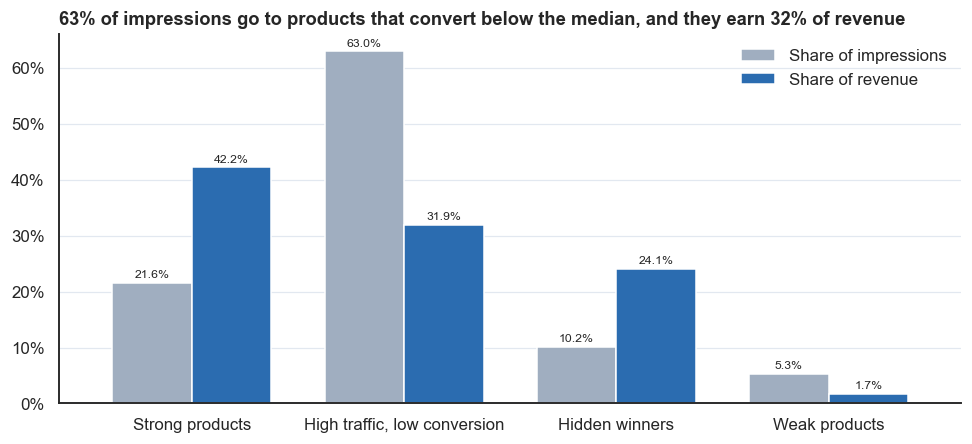

In [30]:
shares = q.set_index("quadrant")[["pct_of_impressions", "pct_of_revenue"]]
ax = shares.plot.bar(figsize=(9, 4.2), color=[GREY, BLUE], rot=0, width=0.75)
light_grid(ax, "y")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)
ax.legend(["Share of impressions", "Share of revenue"], frameon=False)
ax.set_xlabel("")
ax.set_title("63% of impressions go to products that convert below the median, and they earn 32% of revenue")
plt.tight_layout()
plt.show()

In [31]:
heavy = floor[floor.quadrant == "High traffic, low conversion"].nlargest(8, "impressions")[["item_name", "product_group", "impressions", "order_lines", "view_to_purchase_pct", "revenue_usd"]]
heavy.columns = ["Product", "Group", "Impressions", "Orders", "Orders per 100 impr.", "Revenue (USD)"]
hidden = floor[floor.quadrant == "Hidden winners"].nlargest(8, "revenue_usd")[["item_name", "product_group", "impressions", "order_lines", "view_to_purchase_pct", "revenue_usd"]]
hidden.columns = heavy.columns
fmt = {"Impressions": "{:,.0f}", "Orders": "{:,.0f}", "Orders per 100 impr.": "{:.2f}", "Revenue (USD)": "${:,.0f}"}
print("Most-shown products that convert below the median (investigate price, images and description):")
display(heavy.style.format(fmt).hide(axis="index"))
print("Hidden winners with the most revenue (candidates to promote):")
display(hidden.style.format(fmt).hide(axis="index"))

Most-shown products that convert below the median (investigate price, images and description):


Product,Group,Impressions,Orders,Orders per 100 impr.,Revenue (USD)
Google Navy Speckled Tee,Apparel,"54,377",143,0.26,"$4,068"
Google Campus Bike Eco Tee Navy,Apparel,"41,849",42,0.10,"$1,040"
Google Women's Striped L/S,Other,"41,413",82,0.20,"$1,413"
Android Large Removable Sticker Sheet,Stationery and office,"38,277",51,0.13,$215
Android SM S/F18 Sticker Sheet,Stationery and office,"37,566",107,0.28,$311
Google Tee Yellow,Apparel,"33,301",34,0.10,$345
YouTube Icon Tee Grey,Apparel,"32,865",63,0.19,"$1,294"
Google Small Standard Journal Navy,Stationery and office,"32,657",55,0.17,$806


Hidden winners with the most revenue (candidates to promote):


Product,Group,Impressions,Orders,Orders per 100 impr.,Revenue (USD)
Google Men's Tech Fleece Vest Charcoal,Apparel,"4,248",74,1.74,"$5,360"
Google Campus Bike,Fun and gifts,"3,047",103,3.38,"$4,096"
Google Incognito Techpack V2,Bags,"1,179",38,3.22,"$3,703"
Google NYC Campus Zip Hoodie,Apparel,"1,700",76,4.47,"$3,224"
Google Men's Softshell Moss,Apparel,"3,421",31,0.91,"$2,589"
Google Raincoat Navy,Apparel,"1,937",24,1.24,"$2,424"
Google Toddler FC Zip Hoodie,Apparel,"4,618",77,1.67,"$2,268"
Google Sherpa Vest Black,Apparel,"1,359",28,2.06,"$1,844"


**Reading the "high traffic, low conversion" list.** It is led by cheap, widely displayed items: tees at $9 to $25, and sticker sheets and journals at $2 to $6 per unit. Part of the low conversion is simply dilution: the more widely a product is shown, the less intent each impression carries (across established products, impressions and conversion are negatively correlated, r = -0.48 on a log scale). So this list is where to look for fixes in price, imagery and description, but it is not proof that these products are broken.

**Reading the "hidden winners" list.** These products might be bought through search, direct links or repeat purchases that never show up as list impressions, which is partly why their rate per impression looks high. They are still the better candidates for more promotion, because each extra impression they get has historically been worth about 4.7 times as much.

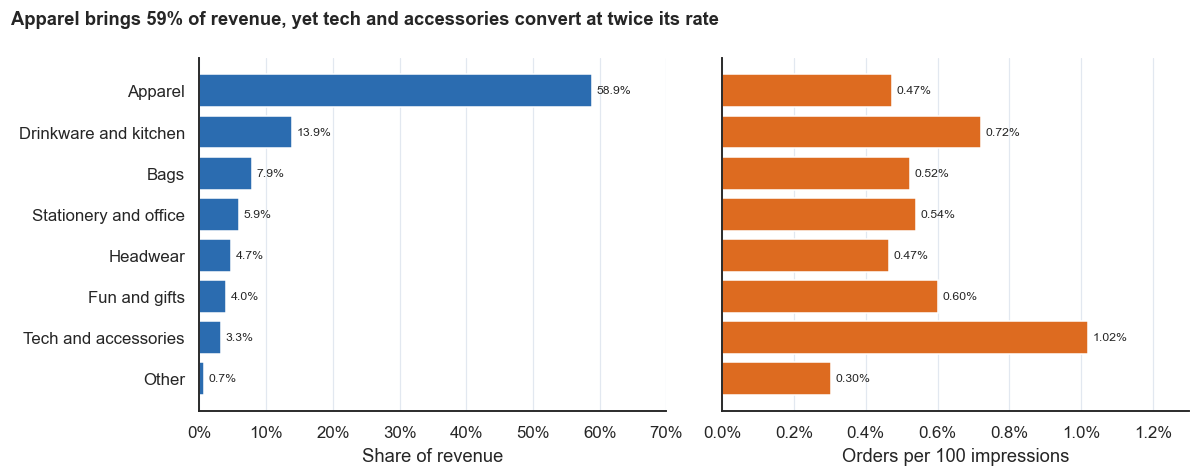

In [32]:
g = groups[groups.product_group != "Gift cards"].sort_values("pct_of_revenue")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
axes[0].barh(g.product_group, g.pct_of_revenue, color=BLUE)
axes[0].bar_label(axes[0].containers[0], fmt="%.1f%%", padding=3, fontsize=8)
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
axes[0].set_xlabel("Share of revenue")
axes[0].set_xlim(0, 70)
light_grid(axes[0], "x")
axes[1].barh(g.product_group, g.view_to_purchase_pct, color=ORANGE)
axes[1].bar_label(axes[1].containers[0], fmt="%.2f%%", padding=3, fontsize=8)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
axes[1].set_xlabel("Orders per 100 impressions")
axes[1].set_xlim(0, 1.3)
light_grid(axes[1], "x")
fig.suptitle("Apparel brings 59% of revenue, yet tech and accessories convert at twice its rate", x=0.01, ha="left", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

Apparel is the business: 153 of 419 products and **58.9% of revenue**, with drinkware and kitchen (13.9%) and bags (7.9%) a distant second and third. Per impression, apparel converts at 0.47% while tech and accessories convert at 1.02% (about twice as well) and drinkware at 0.72%. Gift cards are left out of this chart because their five products have almost no impressions (225) against 59 orders, so their rate is not comparable. Product groups come from keywords in the product name and are approximate; 13 products (0.7% of revenue) did not match any group.

In [33]:
top = products.nlargest(10, "revenue_usd")[["item_name", "product_group", "quadrant", "impressions", "order_lines", "revenue_usd", "avg_unit_price"]].copy()
top.columns = ["Product", "Group", "Quadrant", "Impressions", "Orders", "Revenue (USD)", "Avg unit price"]
sold = products[products.order_lines > 0].sort_values("revenue_usd", ascending=False)
top20_n = int(len(sold) * 0.2)
print(f"Top 10 products: {products.nlargest(10, 'revenue_usd').revenue_usd.sum() / products.revenue_usd.sum() * 100:.1f}% of revenue. Top 20% of sold products ({top20_n} of {len(sold)}): {sold.head(top20_n).revenue_usd.sum() / products.revenue_usd.sum() * 100:.1f}% of revenue.")
top.style.format({"Impressions": "{:,.0f}", "Orders": "{:,.0f}", "Revenue (USD)": "${:,.0f}", "Avg unit price": "${:.2f}"}, na_rep="below floor").hide(axis="index")

Top 10 products: 23.4% of revenue. Top 20% of sold products (78 of 394): 68.7% of revenue.


Product,Group,Quadrant,Impressions,Orders,Revenue (USD),Avg unit price
Google Zip Hoodie F/C,Apparel,Strong products,"46,156",243,"$13,152",$50.58
Google Crewneck Sweatshirt Navy,Apparel,Strong products,"30,650",209,"$9,878",$45.52
Super G Unisex Joggers,Apparel,Strong products,"49,249",272,"$9,103",$30.96
Google Men's Tech Fleece Grey,Apparel,Strong products,"16,743",107,"$8,668",$74.09
Google Badge Heavyweight Pullover Black,Apparel,"High traffic, low conversion","31,785",162,"$8,628",$48.20
Google Crewneck Sweatshirt Green,Apparel,Strong products,"26,910",160,"$7,579",$45.66
Google Sherpa Zip Hoodie Charcoal,Apparel,"High traffic, low conversion","30,866",100,"$6,122",$55.65
Google Men's Puff Jacket Black,Apparel,Strong products,"11,089",59,"$5,750",$95.83
Google Men's Tech Fleece Vest Charcoal,Apparel,Hidden winners,"4,248",74,"$5,360",$66.17
Google Canteen Bottle Black,Drinkware and kitchen,Strong products,"6,244",137,"$5,131",$19.81


In [34]:
unmatched = products[(products.impressions >= 1000) & (products.order_lines == 0)].sort_values("impressions", ascending=False)[["item_name", "impressions", "cart_adds"]]
unmatched.columns = ["Product", "Impressions", "Identified cart adds"]
print(f"{len(unmatched)} products have 1,000+ impressions and no orders. Some may be sold under a name that could not be matched, so they should be checked before being called failures:")
unmatched.style.format({"Impressions": "{:,.0f}", "Identified cart adds": "{:,.0f}"}).hide(axis="index")

8 products have 1,000+ impressions and no orders. Some may be sold under a name that could not be matched, so they should be checked before being called failures:


Product,Impressions,Identified cart adds
Google Land & Sea Unisex Tee,"13,441",258
Google Black Tee,"7,254",360
Google Unisex Pride Eco-Tee Black,"5,744",112
Google Tee Dark Blue,"4,724",146
Google Mountain View Tee Blue,"3,399",16
Google Tracking Hat,"2,845",0
Google Lightweight Crew Sweatshirt Grey,"2,074",54
Google Kids Playful Tee,"1,644",135


**Concentration and caveats.** Revenue is concentrated: the top 10 products bring 23.4% of revenue and the top 20% of sold products (78 of 394) bring 68.7%. Nine of the ten are apparel. The 134 products below the 1,000-impression floor still hold 10.1% of revenue (117 of them sold), so the quadrants describe the established range rather than the whole catalogue. Eight heavily shown products have no recorded orders, probably because they are sold under a different spelling (see the table above), which makes them uncertain rather than confirmed failures. Everything here describes this sample of the store, not its full catalogue, and it measures exposure rather than product-page visits.

## 8. Customer behaviour and retention

**Question:** do first-time visitors come back, and do returning users buy more?

A user is **new** if their lowest session number is 1, and **returning** if they had visited before 1 Nov 2020 (so only their later visits are observed). A "return" is a session on a later calendar day than the first observed visit, within 7 or 30 days.

Two fairness rules apply throughout. Return rates only include users with enough follow-up time (a first visit on or before 1 Jan 2021 for the 30-day rate). And because users who arrive late have less time to come back, new and returning users are also compared over an **equal 30-day window**.

In [35]:
nvr = load("08_new_vs_returning.csv").set_index("user_type").loc[["new", "returning"]]
show = nvr[["users", "pct_of_users", "sessions_per_user", "repeat_visit_rate_pct", "purchase_rate_pct", "revenue_usd", "pct_of_revenue", "revenue_per_user", "aov"]].reset_index()
show.columns = ["User type", "Users", "% of users", "Sessions / user", "Repeat-visit rate %", "Purchase rate %", "Revenue (USD)", "% of revenue", "Revenue / user", "AOV"]
show.style.format({"Users": "{:,.0f}", "% of users": "{:.1f}", "Sessions / user": "{:.2f}", "Repeat-visit rate %": "{:.1f}", "Purchase rate %": "{:.2f}", "Revenue (USD)": "${:,.0f}", "% of revenue": "{:.1f}", "Revenue / user": "${:.2f}", "AOV": "${:.2f}"}).hide(axis="index")

User type,Users,% of users,Sessions / user,Repeat-visit rate %,Purchase rate %,Revenue (USD),% of revenue,Revenue / user,AOV
new,"261,148",96.7,1.30,16.4,1.25,"$263,359",77.6,$1.01,$68.53
returning,"9,006",3.3,2.39,49.4,8.75,"$76,098",22.4,$8.45,$71.52


Over the whole period, returning users are only 3.3% of all users but bring 22.4% of revenue: they make 2.4 sessions each (against 1.3), half of them visit more than once (49.4% against 16.4%), and they buy at 8.75% against 1.25%. This whole-period view is not an even comparison, though, because it gives each group a different amount of time. The equal-window comparison below is the fair one.

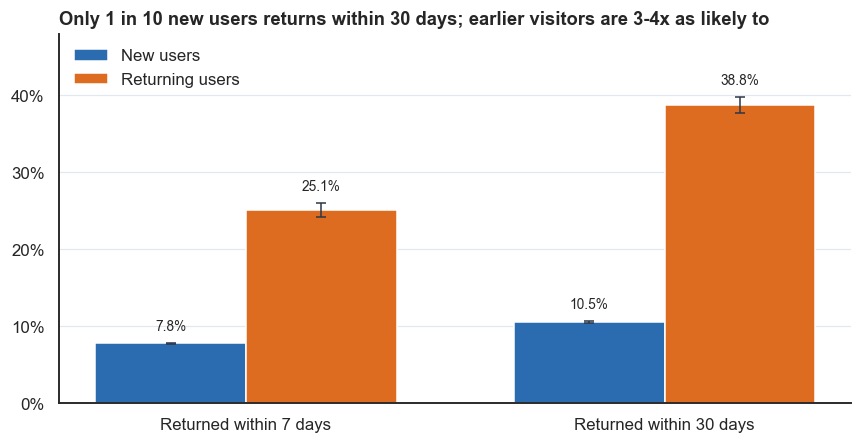

New users: 7.79% returned within 7 days (18,843 of 241,890 eligible); 10.54% within 30 days (18,220 of 172,878 eligible).


In [36]:
ret = load("08_retention_summary.csv")
ret["lo"], ret["hi"] = zip(*[wilson(r, n) for r, n in zip(ret.returned, ret.eligible_users)])
ret["rate"] = ret.returned / ret.eligible_users * 100
ret["err_lo"] = ret.rate - ret.lo * 100
ret["err_hi"] = ret.hi * 100 - ret.rate

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(2)
width = 0.36
for i, (utype, color) in enumerate([("new", BLUE), ("returning", ORANGE)]):
    d = ret[ret.user_type == utype].sort_values("window_days")
    bars = ax.bar(x + (i - 0.5) * width, d.rate, width, yerr=[d.err_lo, d.err_hi], color=color, label=f"{utype.capitalize()} users", error_kw={"ecolor": "#2d3748", "capsize": 3, "lw": 1})
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in d.rate], padding=6, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(["Returned within 7 days", "Returned within 30 days"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
light_grid(ax, "y")
ax.set_ylim(0, 48)
ax.legend(frameon=False, loc="upper left")
ax.set_title("Only 1 in 10 new users returns within 30 days; earlier visitors are 3-4x as likely to")
plt.tight_layout()
plt.show()

new7 = ret[(ret.user_type == "new") & (ret.window_days == 7)].iloc[0]
new30 = ret[(ret.user_type == "new") & (ret.window_days == 30)].iloc[0]
print(f"New users: {new7.rate:.2f}% returned within 7 days ({int(new7.returned):,} of {int(new7.eligible_users):,} eligible); {new30.rate:.2f}% within 30 days ({int(new30.returned):,} of {int(new30.eligible_users):,} eligible).")

**Most first-time visitors do not come back.** Of new users with a full follow-up window, only 7.8% return within 7 days and 10.5% within 30 days, so about 9 in 10 are one-visit customers. Most of the returns happen early: in every weekly cohort with full follow-up, the 7-day rate is already 73% to 81% of the 30-day rate. Users who had visited before the period are far more loyal (25.1% return within 7 days and 38.8% within 30), but they are a self-selected group of existing fans, which is why retention is read for new users.

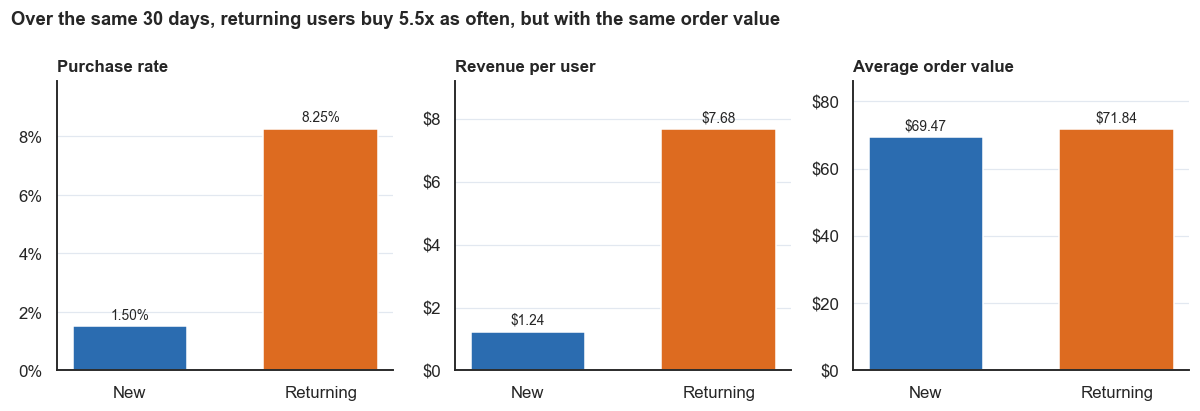

Purchase rate, returning vs new, equal 30-day window: 8.25% vs 1.50% (gap +6.75 pp, z = 44.7, p < 0.001)


In [37]:
win = load("08_new_vs_returning_30d_window.csv").set_index("user_type").loc[["new", "returning"]]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
panels = [("purchase_rate_pct", "Purchase rate", "{:.2f}%", mtick.PercentFormatter(decimals=0)), ("revenue_per_user", "Revenue per user", "${:.2f}", mtick.FuncFormatter(lambda v, _: f"${v:.0f}")), ("aov", "Average order value", "${:.2f}", mtick.FuncFormatter(lambda v, _: f"${v:.0f}"))]
for ax, (col, title, fmt_, axfmt) in zip(axes, panels):
    bars = ax.bar(["New", "Returning"], win[col], color=[BLUE, ORANGE], width=0.6)
    ax.bar_label(bars, labels=[fmt_.format(v) for v in win[col]], padding=3, fontsize=9)
    ax.yaxis.set_major_formatter(axfmt)
    ax.set_ylim(0, win[col].max() * 1.2)
    light_grid(ax, "y")
    ax.set_title(title, fontsize=11)
fig.suptitle("Over the same 30 days, returning users buy 5.5x as often, but with the same order value", x=0.01, ha="left", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

diff, z, p = two_prop_ztest(win.loc["returning", "buyers"], win.loc["returning", "users"], win.loc["new", "buyers"], win.loc["new", "users"])
print(f"Purchase rate, returning vs new, equal 30-day window: {win.loc['returning', 'purchase_rate_pct']:.2f}% vs {win.loc['new', 'purchase_rate_pct']:.2f}% (gap {diff * 100:+.2f} pp, z = {z:.1f}, p < 0.001)")

**Returning users do buy more, and the reason is frequency.** Over the same 30 days, 8.25% of returning users buy against 1.50% of new users, and each returning user brings in $7.68 against $1.24 (6.2 times as much). Their average order value is almost the same ($71.84 against $69.47), so they do not spend more per order; they simply order far more often. This is a comparison of two different groups. Returning users are existing fans, so it shows that loyal customers are worth more, not that bringing a new user back would turn them into one.

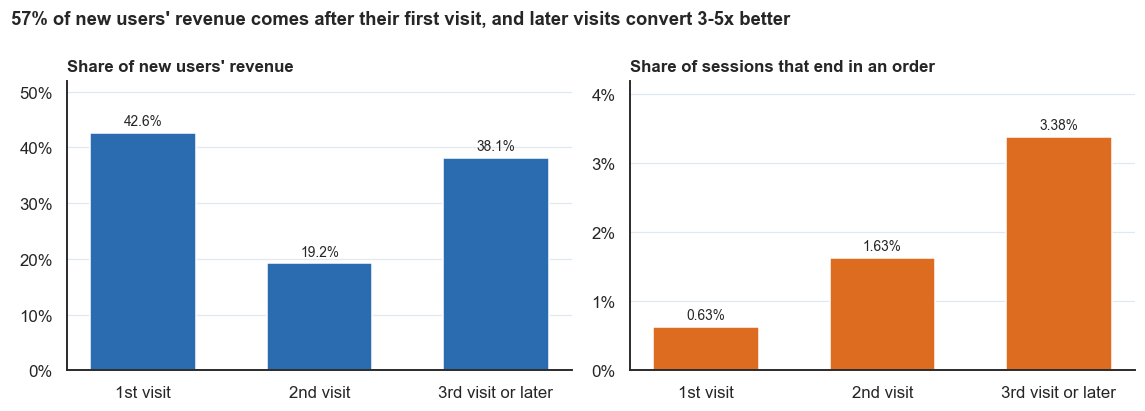

New buyers made their first purchase on their,Buyers,% of buyers,Median days after first visit
First visit,"1,646",50.4,0
Second visit,655,20.1,1
Third visit or later,966,29.6,6


In [38]:
vis = load("08_revenue_by_visit_number.csv")
nv = vis[vis.user_type == "new"].sort_values("min_visit_number")
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
bars = axes[0].bar(nv.visit, nv.pct_of_user_type_revenue, color=BLUE, width=0.6)
axes[0].bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
axes[0].set_ylim(0, 52)
axes[0].set_title("Share of new users' revenue", fontsize=11)
light_grid(axes[0], "y")
bars = axes[1].bar(nv.visit, nv.conversion_rate_pct, color=ORANGE, width=0.6)
axes[1].bar_label(bars, fmt="%.2f%%", padding=3, fontsize=9)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
axes[1].set_ylim(0, 4.2)
axes[1].set_title("Share of sessions that end in an order", fontsize=11)
light_grid(axes[1], "y")
fig.suptitle("57% of new users' revenue comes after their first visit, and later visits convert 3-5x better", x=0.01, ha="left", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

timing = load("08_first_purchase_timing.csv")
t = timing[timing.user_type == "new"][["first_purchase_on", "buyers", "pct_of_buyers", "median_days_after_first_visit"]].copy()
t.columns = ["New buyers made their first purchase on their", "Buyers", "% of buyers", "Median days after first visit"]
t.style.format({"Buyers": "{:,.0f}", "% of buyers": "{:.1f}"}).hide(axis="index")

Half of new buyers (50.4%) buy on their first visit, and every one of them on the same day. The other half need more than one visit: 20.1% buy on their second visit (typically the next day) and 29.6% on their third visit or later, with a median of 6 days after arriving. As a result, 57.4% of the revenue from new users comes from visits after the first, and the chance that a session ends in an order rises from 0.63% on the first visit to 1.63% on the second and 3.38% from the third on. A visitor who comes back is much closer to buying than one who has just arrived.

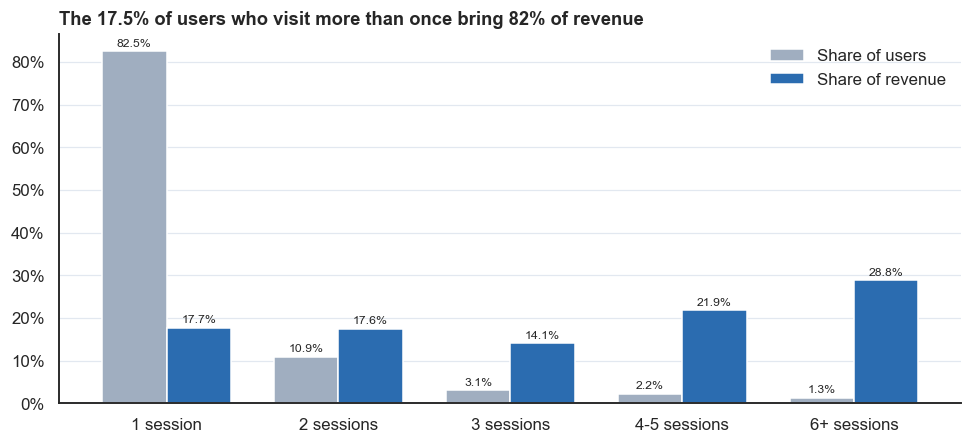

Users with 2+ sessions: 17.5% of users, 82.3% of revenue.


Sessions,Users,Purchase rate %,Revenue / user
1 session,"222,790",0.45,$0.27
2 sessions,"29,536",2.81,$2.02
3 sessions,"8,322",7.47,$5.74
4-5 sessions,"5,925",13.15,$12.52
6+ sessions,"3,581",23.18,$27.33


In [39]:
spu = load("08_sessions_per_user.csv")
spu["multi"] = spu.min_sessions > 1
shares = spu.set_index("sessions_bucket")[["pct_of_users", "pct_of_revenue"]]
ax = shares.plot.bar(figsize=(9, 4.2), color=[GREY, BLUE], rot=0, width=0.75)
light_grid(ax, "y")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)
ax.legend(["Share of users", "Share of revenue"], frameon=False)
ax.set_xlabel("")
ax.set_title("The 17.5% of users who visit more than once bring 82% of revenue")
plt.tight_layout()
plt.show()

multi_users = spu[spu.multi].pct_of_users.sum()
multi_revenue = spu[spu.multi].pct_of_revenue.sum()
print(f"Users with 2+ sessions: {multi_users:.1f}% of users, {multi_revenue:.1f}% of revenue.")
spu[["sessions_bucket", "users", "purchase_rate_pct", "revenue_per_user"]].rename(columns={"sessions_bucket": "Sessions", "users": "Users", "purchase_rate_pct": "Purchase rate %", "revenue_per_user": "Revenue / user"}).style.format({"Users": "{:,.0f}", "Purchase rate %": "{:.2f}", "Revenue / user": "${:.2f}"}).hide(axis="index")

Users who visit once (82.5% of all users) buy at 0.45% and bring $0.27 each, while those with six or more sessions (1.3% of users) buy at 23.2% and bring $27.33 each. In total, the 17.5% of users with at least two sessions account for 82.3% of revenue. This is an association and should not be read as "more visits cause more purchases": buying itself creates sessions (people return to finish checkout or check an order), and a user with more sessions simply had more chances to buy.

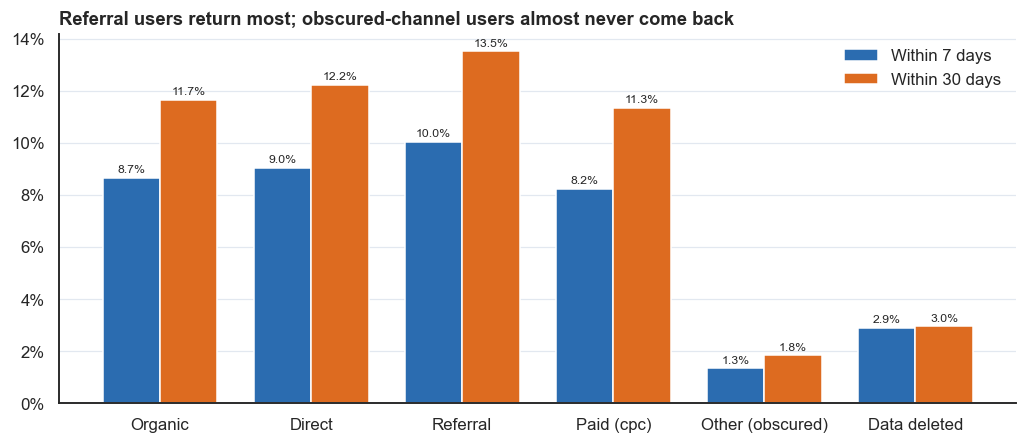

In [40]:
ch = load("08_retention_by_channel.csv").set_index("acq_channel").loc[["Organic", "Direct", "Referral", "Paid (cpc)", "Other (obscured)", "Data deleted"]]
x = np.arange(len(ch))
fig, ax = plt.subplots(figsize=(9.5, 4.2))
b1 = ax.bar(x - 0.19, ch.return_7d_pct, 0.38, color=BLUE, label="Within 7 days")
b2 = ax.bar(x + 0.19, ch.return_30d_pct, 0.38, color=ORANGE, label="Within 30 days")
ax.bar_label(b1, fmt="%.1f%%", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.1f%%", padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(ch.index)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
light_grid(ax, "y")
ax.legend(frameon=False)
ax.set_title("Referral users return most; obscured-channel users almost never come back")
plt.tight_layout()
plt.show()

Among new users, referral has the best retention (10.0% return within 7 days, 13.5% within 30), followed by direct, organic and paid, which are close together (11.3% to 12.2% within 30 days). The **obscured-channel users barely return at all: 1.3% within 7 days and 1.8% within 30**, which fits their very low conversion in the channel analysis. These look like one-visit traffic, possibly bots or an artefact of obscuring, but the sample cannot tell. The `Data deleted` group is too small (589 eligible users) to read much into.

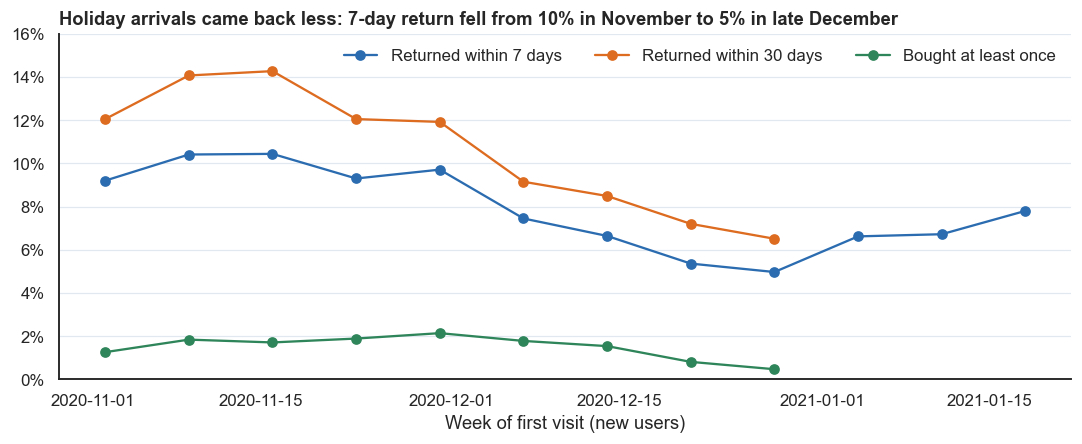

In the 8 weekly cohorts with full 30-day follow-up, the 7-day return rate is 73% to 81% of the 30-day rate.


In [41]:
cw = load("08_retention_by_cohort_week.csv")
cw["cohort_week"] = pd.to_datetime(cw.cohort_week)
cw = cw[cw.cohort_week >= "2020-11-02"]
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(cw.cohort_week, cw.return_7d_pct, marker="o", color=BLUE, label="Returned within 7 days")
ax.plot(cw.cohort_week, cw.return_30d_pct, marker="o", color=ORANGE, label="Returned within 30 days")
buy = cw[cw.cohort_week <= "2020-12-28"]  # later cohorts have under a month left to buy
ax.plot(buy.cohort_week, buy.purchase_rate_pct, marker="o", color="#2f855a", label="Bought at least once")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
light_grid(ax, "y")
ax.set_ylim(0, 16)
ax.legend(frameon=False, ncol=3, loc="upper right")
ax.set_xlabel("Week of first visit (new users)")
ax.set_title("Holiday arrivals came back less: 7-day return fell from 10% in November to 5% in late December")
plt.tight_layout()
plt.show()

full = cw[cw.eligible_30d_users == cw.new_users]
ratio = (full.return_7d_pct / full.return_30d_pct) * 100
print(f"In the {len(full)} weekly cohorts with full 30-day follow-up, the 7-day return rate is {ratio.min():.0f}% to {ratio.max():.0f}% of the 30-day rate.")

Return rates were best for visitors who first arrived in the middle of November (about 10.4% within 7 days) and fell steadily through December to 5.0% for the week starting 28 December, before recovering a little in January. The first week (starting 26 October) contains only 1 November and is left out. Visitors who first arrived in the week of 30 November (Cyber Monday week) converted best (2.14% bought, against 1.26% in the first full week of November, and 1.89% in the Black Friday week), but holiday visitors were less likely to come back, which suggests more one-off gift shoppers and browsers. The buying line stops at the week of 28 December, because later cohorts have under a month left in the data to make a purchase.

**Caveats for the retention analysis.** "Returning" users are a self-selected group of earlier visitors, and their true first visit is unknown, so retention is measured for new users only. Return rates use a calendar-day definition (a second session on the same day does not count as a return), which makes them stricter than a "repeat-visit" measure. The sessions-per-user results are associations, not effects. Everything describes this sample over three months, so long-term retention beyond 30 days is not visible.

## 9. Seasonality

**Question:** did holiday traffic turn into more purchases and revenue, or just more browsing?

There is no prior-year data, so every comparison is against the **early-November baseline** and never year over year. The periods are early November (1-14 Nov), the Black Friday / Cyber Monday week (24-30 Nov), December, and January. Periods differ in length, so they are compared **per day**.

Two data issues shape the periods (see the tracking gaps in the data quality section): January is compared on **1-25 January only**, because from 26 January most purchase events lose their revenue; and no cart step is compared across periods, because `add_to_cart` is missing for most of the baseline.

In [42]:
ps = load("09_period_summary.csv")
comp = ps[ps.is_comparison].copy()
tbl = comp[["period", "days", "avg_daily_users", "sessions_per_day", "orders_per_day", "revenue_per_day", "session_conversion_pct", "aov"]].copy()
tbl.columns = ["Period", "Days", "Users / day", "Sessions / day", "Orders / day", "Revenue / day", "Conversion % (sessions)", "AOV"]
tbl.style.format({"Users / day": "{:,.0f}", "Sessions / day": "{:,.0f}", "Orders / day": "{:.1f}", "Revenue / day": "${:,.0f}", "Conversion % (sessions)": "{:.2f}", "AOV": "${:.2f}"}).hide(axis="index")

Period,Days,Users / day,Sessions / day,Orders / day,Revenue / day,Conversion % (sessions),AOV
Early November (baseline),14,"2,958","3,422",46.1,"$3,190",1.21,$69.23
Black Friday / Cyber Monday week,7,"3,537","4,058",85.3,"$6,803",1.94,$79.77
December,31,"3,819","4,302",74.3,"$5,101",1.52,$68.67
January (1-25),25,"3,462","3,838",33.6,"$2,174",0.83,$64.64


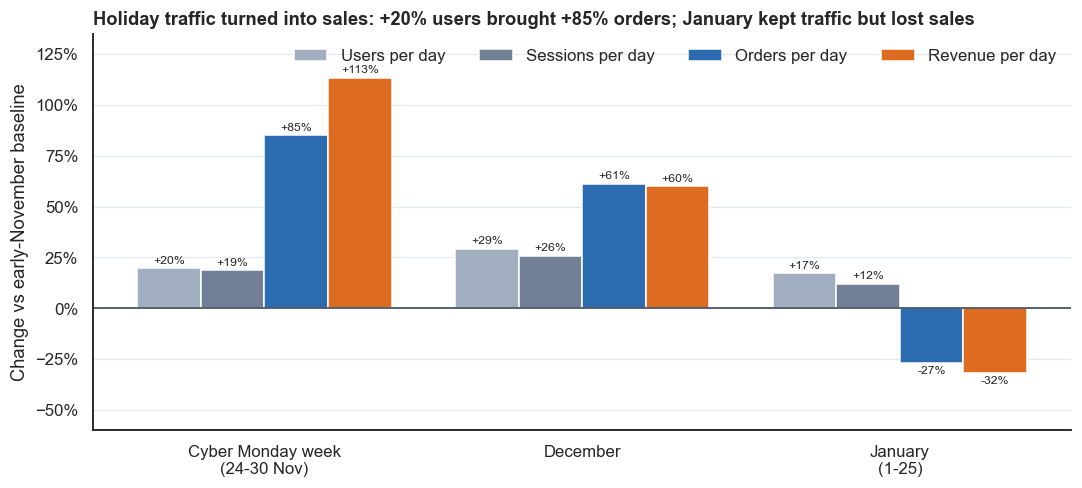

In [43]:
others = comp[comp.period_order > 1].copy()
names = {"Black Friday / Cyber Monday week": "Cyber Monday week\n(24-30 Nov)", "December": "December", "January (1-25)": "January\n(1-25)"}
metrics = [("Users per day", "daily_users_vs_baseline_pct", "#a0aec0"), ("Sessions per day", "sessions_per_day_vs_baseline_pct", "#718096"),
           ("Orders per day", "orders_per_day_vs_baseline_pct", BLUE), ("Revenue per day", "revenue_per_day_vs_baseline_pct", ORANGE)]
x = np.arange(len(others))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 4.6))
for i, (label, col, color) in enumerate(metrics):
    bars = ax.bar(x + (i - 1.5) * width, others[col], width, label=label, color=color)
    ax.bar_label(bars, labels=[f"{v:+.0f}%" for v in others[col]], padding=2, fontsize=8)
ax.axhline(0, color="#2d3748", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([names[p] for p in others.period])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
light_grid(ax, "y")
ax.set_ylim(-60, 135)
ax.legend(frameon=False, ncol=4, loc="upper right")
ax.set_ylabel("Change vs early-November baseline")
ax.set_title("Holiday traffic turned into sales: +20% users brought +85% orders; January kept traffic but lost sales")
plt.tight_layout()
plt.show()

**Yes, holiday traffic turned into purchases.** In the Cyber Monday week there were 20% more users per day than in early November, but **85% more orders per day and 113% more revenue**: conversion rose from 1.21% to 1.94% of sessions, and the average order was 15% bigger ($79.77 against $69.23). December kept most of that: 29% more users per day, 61% more orders and 60% more revenue, at an almost unchanged order value (-1%) and 1.52% conversion. **January was the opposite: browsing without buying.** Traffic stayed above the baseline (+17% users, +12% sessions per day) while orders fell 27%, revenue 32% and conversion to 0.83%.

In [44]:
base_orders, base_days = 645, 14
repeats = 35
adj_per_day = (base_orders - repeats) / base_days
print("Orders per day vs baseline, if the 35 apparent repeat orders in the baseline were removed:")
for _, r in others.iterrows():
    print(f"  {r.period}: measured {r.orders_per_day_vs_baseline_pct:+.0f}%, adjusted {(r.orders_per_day / adj_per_day - 1) * 100:+.0f}%")

Orders per day vs baseline, if the 35 apparent repeat orders in the baseline were removed:
  Black Friday / Cyber Monday week: measured +85%, adjusted +96%
  December: measured +61%, adjusted +71%
  January (1-25): measured -27%, adjusted -23%


**Sensitivity to the baseline.** All early-November purchase events lack a transaction id, so repeats could not be removed there, and about 35 of the baseline's 645 orders look like repeats (same user, session and revenue). Taking them out would lower the baseline to about 43.6 orders per day, which would make the order uplifts larger, not smaller: roughly +96% in the Cyber Monday week, +71% in December and -23% in January (against +85%, +61% and -27% as measured). The conclusion does not change, and the measured numbers are the conservative ones.

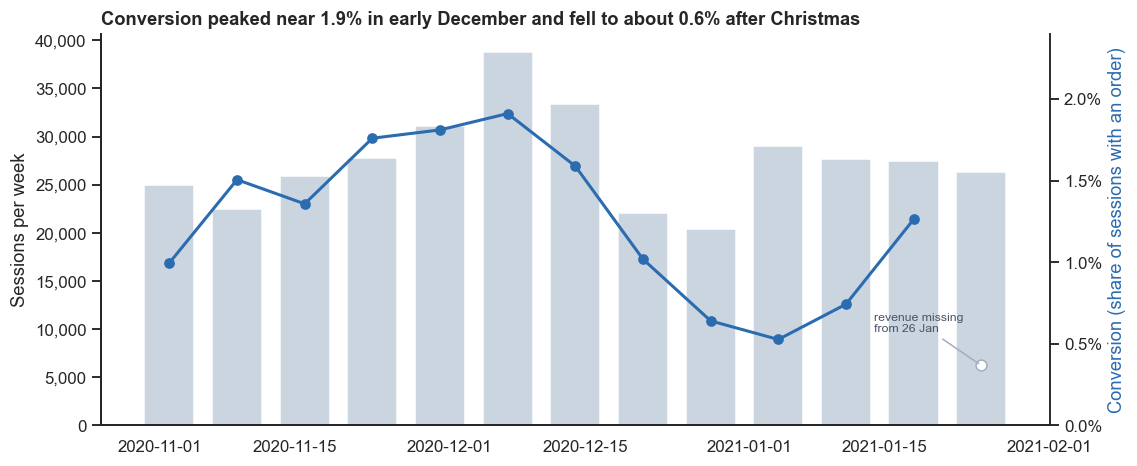

In [45]:
wk = load("09_weekly_trend.csv")
wk["week_start"] = pd.to_datetime(wk.week_start)
wk = wk[wk.days_in_data == 7].copy()
rel = wk[wk.purchase_data_reliable]
unrel = wk[~wk.purchase_data_reliable]

fig, ax = plt.subplots(figsize=(10.5, 4.4))
ax.bar(wk.week_start, wk.sessions, width=5.2, color="#cbd5e0")
thousands(ax, "y")
ax.set_ylabel("Sessions per week")
ax2 = ax.twinx()
ax2.plot(rel.week_start, rel.session_conversion_pct, color=BLUE, marker="o", lw=2)
ax2.scatter(unrel.week_start, unrel.session_conversion_pct, facecolors="white", edgecolors=GREY, s=50, zorder=3)
ax2.annotate("revenue missing\nfrom 26 Jan", (unrel.week_start.iloc[0], unrel.session_conversion_pct.iloc[0]), xytext=(-70, 22), textcoords="offset points", fontsize=8, color="#4a5568", arrowprops={"arrowstyle": "-", "color": GREY})
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax2.set_ylim(0, 2.4)
ax2.set_ylabel("Conversion (share of sessions with an order)", color=BLUE)
ax2.spines["right"].set_visible(True)
ax.set_title("Conversion peaked near 1.9% in early December and fell to about 0.6% after Christmas")
plt.tight_layout()
plt.show()

Weekly traffic (grey bars) follows the calendar: it rises into the first half of December and dips over Christmas and New Year. Conversion (blue line) climbs from about 1.0% in the first week of November to **1.9% in the week of 7 December**, then drops to about 1.0% in the week of 21 December and 0.64% in the week after, bottoming at 0.53% in the first week of January. It partly recovers in mid-January (1.26% in the week of 18 January). The first week (1 November only) is left out, and the last week is shown with an open marker because its revenue is incomplete.

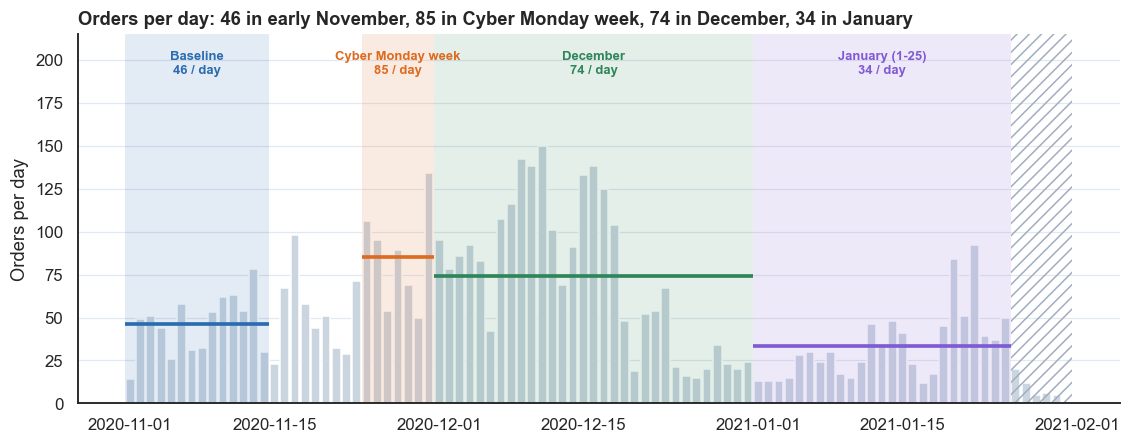

In [46]:
daily = load("09_daily_trend.csv")
daily["date"] = pd.to_datetime(daily["date"])
fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.bar(daily.date, daily.orders, width=0.85, color="#cbd5e0")
spans = [("2020-11-01", "2020-11-14", BLUE, "Baseline"), ("2020-11-24", "2020-11-30", ORANGE, "Cyber Monday week"),
         ("2020-12-01", "2020-12-31", "#2f855a", "December"), ("2021-01-01", "2021-01-25", "#805ad5", "January (1-25)")]
per_day = {"Baseline": ps[ps.period_order == 1].orders_per_day.iloc[0], "Cyber Monday week": ps[ps.period_order == 2].orders_per_day.iloc[0],
           "December": ps[ps.period_order == 3].orders_per_day.iloc[0], "January (1-25)": ps[ps.period_order == 4].orders_per_day.iloc[0]}
for start, end, color, label in spans:
    s, e = pd.Timestamp(start) - pd.Timedelta(hours=12), pd.Timestamp(end) + pd.Timedelta(hours=12)
    ax.axvspan(s, e, color=color, alpha=0.13, lw=0)
    ax.hlines(per_day[label], s, e, color=color, lw=2.4)
    ax.text(s + (e - s) / 2, 205, f"{label}\n{per_day[label]:.0f} / day", ha="center", va="top", fontsize=8.5, color=color, fontweight="bold")
ax.axvspan(pd.Timestamp("2021-01-26") - pd.Timedelta(hours=12), pd.Timestamp("2021-01-31") + pd.Timedelta(hours=12), facecolor="none", edgecolor=GREY, hatch="///", lw=0)
ax.set_ylim(0, 215)
ax.set_ylabel("Orders per day")
light_grid(ax, "y")
ax.set_title("Orders per day: 46 in early November, 85 in Cyber Monday week, 74 in December, 34 in January")
plt.tight_layout()
plt.show()

Daily orders (bars) make the same point day by day, with each period's average as a coloured line. The hatched block at the right is the last six days, where revenue is missing from most purchase events, so those bars are too low. A traffic spike on 8 December (7,562 sessions, about 40% above the day before) did not come with more product views (1,443 against 1,216), so part of December's extra traffic was low-engagement.

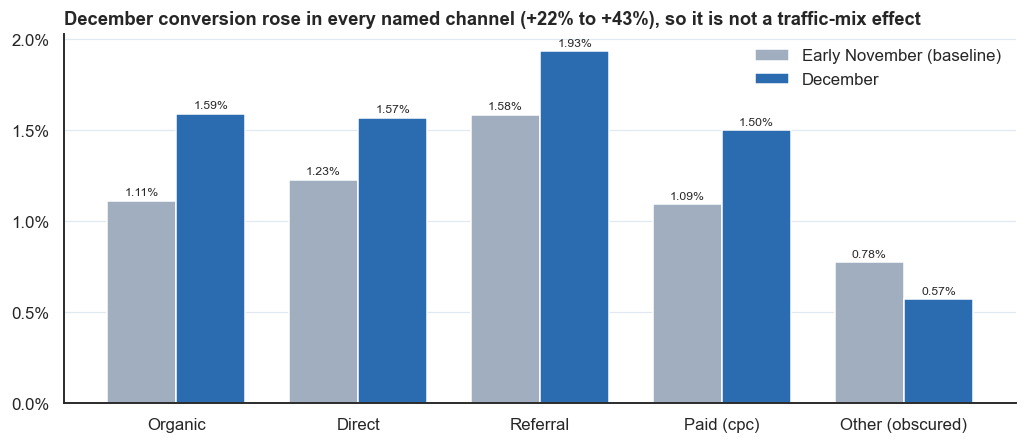

Change in conversion, December vs baseline: {'Organic': '+43%', 'Direct': '+28%', 'Referral': '+22%', 'Paid (cpc)': '+37%', 'Other (obscured)': '-26%'}


In [47]:
mix = load("09_period_channel_mix.csv")
conv = mix.pivot(index="acq_channel", columns="period_order", values="session_conversion_pct")
order = ["Organic", "Direct", "Referral", "Paid (cpc)", "Other (obscured)"]
conv = conv.loc[order]
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9.5, 4.2))
b1 = ax.bar(x - 0.19, conv[1], 0.38, color=GREY, label="Early November (baseline)")
b2 = ax.bar(x + 0.19, conv[3], 0.38, color=BLUE, label="December")
ax.bar_label(b1, fmt="%.2f%%", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.2f%%", padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.yaxis.set_major_locator(mtick.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
light_grid(ax, "y")
ax.legend(frameon=False)
ax.set_title("December conversion rose in every named channel (+22% to +43%), so it is not a traffic-mix effect")
plt.tight_layout()
plt.show()
print("Change in conversion, December vs baseline:", {c: f"{(conv.loc[c, 3] / conv.loc[c, 1] - 1) * 100:+.0f}%" for c in order})

The holiday lift is not an artefact of a changing audience. Conversion rose in every named channel (organic +43%, paid +37%, direct +28%, referral +22%), and the traffic mix barely moved: the obscured group went from 10.5% to 11.9% of sessions, and its own conversion actually fell (0.78% to 0.57%).

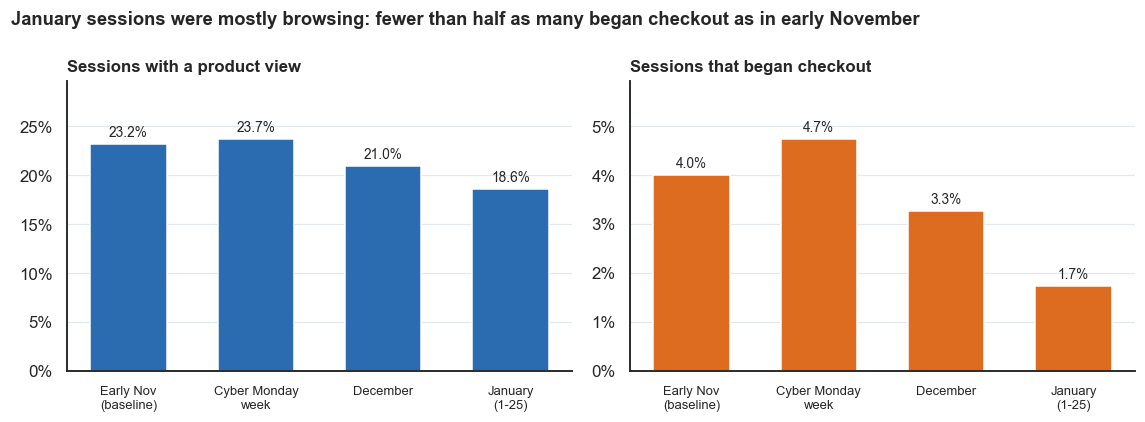

In [48]:
pf = load("09_period_funnel.csv")
short = {"Early November (baseline)": "Early Nov\n(baseline)", "Black Friday / Cyber Monday week": "Cyber Monday\nweek", "December": "December", "January (1-25)": "January\n(1-25)"}
x = np.arange(len(pf))
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))
for ax, col, title, color in [(axes[0], "product_view_pct_of_sessions", "Sessions with a product view", BLUE), (axes[1], "begin_checkout_pct_of_sessions", "Sessions that began checkout", ORANGE)]:
    bars = ax.bar(x, pf[col], color=color, width=0.6)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([short[p] for p in pf.period], fontsize=8.5)
    ax.yaxis.set_major_locator(mtick.MultipleLocator(5 if col == "product_view_pct_of_sessions" else 1))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.set_ylim(0, pf[col].max() * 1.25)
    light_grid(ax, "y")
    ax.set_title(title, fontsize=11)
fig.suptitle("January sessions were mostly browsing: fewer than half as many began checkout as in early November", x=0.01, ha="left", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

Down the funnel, the Cyber Monday week looks like the baseline with extra intent (4.7% of sessions began checkout against 4.0%). January is where engagement fades: only 18.6% of sessions viewed a product (23.2% in the baseline) and 1.7% began checkout, **less than half the baseline rate**. Only these steps are compared across periods, because the cart event is missing for most of the baseline.

**Caveats for the seasonality analysis.** Only the early-November baseline, one holiday week and two months are available, with no prior year, so these are within-period comparisons and cannot separate holiday effects from other changes over the three months. The baseline's orders and revenue may be overstated by about 5% (repeats that could not be removed), which makes the measured uplifts conservative. The last six days of January are excluded from the January comparison because their revenue is largely missing. The data is a sample of the store, so these are patterns in the sample and not exact real-world revenue.

## 10. Key findings

Six findings, each backed by a number from the analysis above. Funnel numbers use the period from 26 November 2020, when cart tracking works (see the tracking gaps in the data quality section).

1. **Four in five users never view a product, and 73% of viewers never add to cart.** Of 209,907 users, 21.5% view a product and 26.7% of those add to cart, so only **1.43% of users (6.7% of viewers) buy**.
2. **About half of cart users never start checkout, and a third of those who do never add payment details.** Only 54.1% of users who add to cart begin checkout (44.1% in a strict sequence), and 34.7% of those who begin never add payment details. Cart abandonment is 79.2% and checkout abandonment 53.8%.
3. **Referral users are the most valuable, and paid users are no better than organic.** Referral users convert at **2.08% against 1.55% for organic** (p < 0.001) and bring $1.82 each against a $1.26 average. Paid converts at 1.45% (p = 0.36 against organic). Obscured traffic is 15.1% of users but only 4.4% of revenue, and just 1.8% of its new users return within 30 days.
4. **The products shown most earn the least per view.** The 98 most-shown low-converting products get 63.0% of impressions and earn $59 per 1,000, while 98 "hidden winners" get 10.2% of impressions and earn **$278 per 1,000 (4.7 times as much)**. Apparel is 58.9% of revenue.
5. **Nine in ten new users never come back, but those who do carry the revenue.** Only 10.5% of new users return within 30 days. The 17.5% of users with two or more sessions bring **82.3% of revenue**, and over the same 30 days returning users buy at 8.25% against 1.50% for new users.
6. **Holiday traffic turned into sales, then faded.** In the Cyber Monday week, 20% more users per day brought **85% more orders** and 113% more revenue; December had 61% more orders. In January (1-25) traffic stayed 17% above baseline, but orders fell 27% and conversion dropped to 0.83%.

**What the data ruled out.** Device is not the problem: mobile converts at 1.27% against 1.21% on desktop (p = 0.11) and no funnel step differs significantly, so a mobile checkout redesign is not justified. Country does not separate markets either: among the 35 countries with 1,000+ users, none differs significantly from average after correcting for multiple comparisons, although four markets (US, India, Canada, UK) bring 66% of revenue.

## 11. Recommendations

Three recommendations, ranked by estimated revenue impact. Each has the same four parts: the finding, the evidence, why the business should care, and what to do first.

In [49]:
HAIRCUT = 0.5  # marginal users are assumed to be worth half the average user

fsteps = load("04_funnel_steps.csv").set_index("stage")
aband = load("04_funnel_abandonment.csv").set_index("level")
wval = load("04_funnel_window_value.csv").iloc[0]
chf = load("05_channel_funnel.csv").set_index("acq_channel")
rch = load("08_retention_by_channel.csv")
rval = load("08_returner_value.csv").set_index("returned_within_30d")

win_days = wval.days_in_window
to_month = 30 / win_days
rev_per_buyer = wval.revenue_per_buyer
monthly_revenue = wval.revenue_usd * to_month

u = fsteps.users
view, cart, chk, pay, buy = u["Product view"], u["Add to cart"], u["Begin checkout"], u["Add payment info"], u["Purchase"]

# 1. win back first-time visitors: new-user 30-day return rate up to the best channel's rate
eligible = rch.eligible_30d_users.sum()
ret_now = rch.returned_30d.sum() / eligible
ret_goal = rch.set_index("acq_channel").loc["Referral", "return_30d_pct"] / 100
extra_returners = eligible * (ret_goal - ret_now)
value_per_returner = rval.loc[True, "revenue_per_user"] - rval.loc[False, "revenue_per_user"]
span_days = 62  # first visits 1 Nov - 1 Jan, the users with a full 30 days of follow-up
full_1 = extra_returners * value_per_returner * 30 / span_days

# 2. cart -> checkout and checkout -> payment up to the best channel's rates
c_goal = chf.loc["Referral", "checkout_pct_of_cart"] / 100
p_goal = chf.loc["Referral", "payment_pct_of_checkout"] / 100
buyers_goal = cart * c_goal * p_goal * (buy / pay)
extra_buyers_2 = buyers_goal - buy
full_2 = extra_buyers_2 * rev_per_buyer * to_month

# 3. view -> cart up to the best channel's rate
v_goal = chf.loc["Referral", "cart_pct_of_view"] / 100
extra_cart = view * (v_goal - cart / view)
cart_buys = 1 - aband.loc["users", "cart_abandonment_pct"] / 100
extra_buyers_3 = extra_cart * cart_buys
full_3 = extra_buyers_3 * rev_per_buyer * to_month

sizing = pd.DataFrame([
    {"Rank": 1, "Recommendation": "Win back first-time visitors", "Change tested": f"30-day return rate {ret_now * 100:.1f}% to {ret_goal * 100:.1f}%", "Extra users": f"+{extra_returners:,.0f} returners", "Upper bound / month": full_1, "Estimate / month": full_1 * HAIRCUT, "Confidence": "Low to medium"},
    {"Rank": 2, "Recommendation": "Fix cart, checkout and payment", "Change tested": f"cart to checkout {chk / cart * 100:.1f}% to {c_goal * 100:.1f}%; checkout to payment {pay / chk * 100:.1f}% to {p_goal * 100:.1f}%", "Extra users": f"+{extra_buyers_2:,.0f} buyers", "Upper bound / month": full_2, "Estimate / month": full_2 * HAIRCUT, "Confidence": "Medium"},
    {"Rank": 3, "Recommendation": "Improve product discovery", "Change tested": f"view to cart {cart / view * 100:.1f}% to {v_goal * 100:.1f}%", "Extra users": f"+{extra_buyers_3:,.0f} buyers", "Upper bound / month": full_3, "Estimate / month": full_3 * HAIRCUT, "Confidence": "Low to medium"},
])
sizing["% of monthly revenue"] = sizing["Estimate / month"] / monthly_revenue * 100
print(f"Average monthly revenue in the funnel window: ${monthly_revenue:,.0f}. Revenue per buyer: ${rev_per_buyer:.2f}. Value of a returner (upper bound): ${value_per_returner:.2f}.")
sizing.style.format({"Upper bound / month": "${:,.0f}", "Estimate / month": "${:,.0f}", "% of monthly revenue": "{:.1f}%"}).hide(axis="index")

Average monthly revenue in the funnel window: $110,730. Revenue per buyer: $82.16. Value of a returner (upper bound): $7.92.


Rank,Recommendation,Change tested,Extra users,Upper bound / month,Estimate / month,Confidence,% of monthly revenue
1,Win back first-time visitors,30-day return rate 10.5% to 13.5%,"+5,136 returners","$19,679","$9,840",Low to medium,8.9%
2,"Fix cart, checkout and payment",cart to checkout 54.1% to 56.4%; checkout to payment 65.3% to 69.8%,+336 buyers,"$12,379","$6,190",Medium,5.6%
3,Improve product discovery,view to cart 26.7% to 29.0%,+224 buyers,"$8,239","$4,119",Low to medium,3.7%


### How the impact is estimated

Each recommendation is sized the same way, as a scenario and not a forecast: *raise this step to the level of the best-performing channel in the sample (referral), count the extra users, and value them at what the sample shows.* A 50% haircut is then applied, because users won over by a change are likely to be worth less than the average. The "upper bound" column shows the figure without the haircut. Buyers are valued at the average revenue per buyer ($82.16 in the funnel window), and a returning user at the gap in revenue between new users who came back within 30 days and those who did not ($7.92 over the same 30 days). These are sizes of opportunity to prioritise tests, not promises of revenue.

### Recommendation 1: win back first-time visitors

| Part | |
| --- | --- |
| **Finding** | Most first-time visitors never come back, but the ones who do are worth far more than the ones who do not. |
| **Evidence** | Only **10.5%** of new users return within 30 days (7.8% within 7). New users who return spend **$8.32** over those 30 days against **$0.40** for those who do not (purchase rate 8.8% against 0.64%). The 17.5% of users with two or more sessions bring **82.3% of revenue**, and 57% of new users' revenue comes after their first visit. Referral users return at 13.5%, so a higher rate is achievable. |
| **Implication** | Matching the referral return rate across all new users would bring back about 5,100 extra users in the 62 days of eligible visitors, worth up to **$19.7K a month** and about **$9.8K a month (8.9% of revenue)** after the haircut. This is the largest estimated opportunity. |
| **Recommendation** | Start a re-engagement programme for first-time visitors and cart abandoners in their first week, when most returns happen (for example a reminder email or remarketing), and run it against a holdout group. Judge it by 7-day return rate and 30-day revenue per user. |

*Confidence is the lowest of the three.* Returners may simply be more interested people, so part of the $7.92 gap is selection and not something a campaign can create, and referral users are a different audience from the rest. Only the holdout test can show how much of the gap a campaign can win.

### Recommendation 2: fix the path from cart to payment

| Part | |
| --- | --- |
| **Finding** | About half of the users who add to cart never begin checkout, and a third of those who begin never add payment details. |
| **Evidence** | **54.1%** of cart users begin checkout (**44.1%** in a strict sequence), so 46% to 56% are lost. **65.3%** of checkout starters add payment info, so 34.7% are lost. Cart abandonment is 79.2% and checkout abandonment 53.8%. The pattern is the same on desktop and mobile (no step differs significantly), so it is not a device problem. |
| **Implication** | If these two steps matched the referral users' rates (56.4% and 69.8%), the sample would have gained about 336 buyers in 67 days (+11%), worth up to **$12.4K a month** and about **$6.2K a month (5.6% of revenue)** after the haircut. |
| **Recommendation** | Review the cart page and the move into checkout before increasing ad spend: look at cost surprises such as shipping and taxes, forced account creation, promo-code friction, page speed and available payment methods. Test one change at a time against the current flow. |

*Confidence is medium.* The ranking of these steps is solid, but the cause is not visible in this data, and the cart step is only partly tracked (17% of purchasers have no recorded cart event even from 26 November), so the cart-to-checkout estimate is a range and not a point.

### Recommendation 3: improve product discovery

| Part | |
| --- | --- |
| **Finding** | Shoppers are not being shown the products that sell: the most-shown products earn the least per view, and 73% of product viewers never add to cart. |
| **Evidence** | 98 high-traffic, low-conversion products get **63.0% of impressions** but earn **$59 per 1,000**, while 98 hidden winners get 10.2% of impressions and earn **$278 per 1,000**. Only **26.7%** of product viewers add to cart. Apparel is 58.9% of revenue yet converts at less than half the rate of tech and accessories per impression. |
| **Implication** | Lifting add-to-cart to the referral level (29.0%) would add about 224 buyers in 67 days, worth up to **$8.2K a month** and about **$4.1K a month (3.7% of revenue)** after the haircut. Separately, moving 10% of impressions from low-yield products to hidden winners is worth about $4.3K a month at half their historical yield; the two overlap and should not be added. |
| **Recommendation** | Give the hidden winners (for example Men's Tech Fleece Vest, Campus Bike, Incognito Techpack V2, NYC Campus Zip Hoodie) more prominent placement and test it, and review price, images and descriptions for the most-shown products that convert below the median. |

*Confidence is low to medium.* Views are impressions (a product shown in a list), conversion per impression falls as exposure rises, and some hidden winners may sell through search or direct links that never show as impressions.

### Before any of this is tested: fix the measurement

Three tracking problems limit how precisely any of these changes could be measured, so they should be fixed first: `add_to_cart` events were missing for most of 1-25 November and are still absent for about 17% of purchasers; transaction ids were missing until about 11 November; and from 26 January most purchase events carry no revenue. Without reliable cart, order and revenue tracking, a test of any recommendation above would be hard to read.

### Limitations

- This is a sample of the store over three months, so findings describe the sample, not the real-world store or its exact revenue.
- Channel is the first observed acquisition channel and not the source of each visit, and about a third of events have an obscured source.
- There is no prior-year data and no advertising cost, so seasonality is a within-period comparison and nothing here measures return on ad spend.
- Impact estimates are scenarios built on observational data and stated assumptions; they are for prioritising tests.
- Product "views" are impressions, product groups are keyword-derived, and up to about 230 orders (4.7% of all orders) are missing from the last six days of January.